In [3]:
#!/usr/bin/env python3
"""
=============================================================================
MYELOID INFLAMMASOME PARADOX — DONOR-LEVEL VALIDATION
=============================================================================
Paper 1 Core Claim: "Fire + Firewall" in IT phase
  Fire = Inflammasome activation (NLRP3, IL1B, CASP1, GSDMD, IL18)
  Firewall = Immune evasion brakes (TNFAIP3, IDO1, LGALS9, IL1RN, TGFB1)

This is the MAIN TOPIC of Paper 1. All previous donor-level work was on
CR/NK (secondary findings). Now we validate the foundation.

ANALYSIS PLAN:
  Part 1: Inflammasome pathway (AUCell) — Myeloid NL vs IT, donor-level
  Part 2: 9 Inflammasome genes — Myeloid, individual donor-level
  Part 3: Immune evasion pathway (AUCell) — Myeloid NL vs IT, donor-level
  Part 4: 5 Brake genes — Myeloid, individual donor-level
  Part 5: IL1B/IL1RN ratio — Myeloid, donor-level
  Part 6: Inflammasome cross-lineage — Is it truly Myeloid-specific?
  Part 7: Brake genes cross-lineage — Is immune evasion Myeloid-specific?
  Part 8: Full 5-stage trajectory for key genes (NL→IT→IA→AR→CR)
  Part 9: GSDMD assembly checkpoint re-evaluation
=============================================================================
"""
!pip install -q scanpy leidenalg pyscenic gseapy openpyxl

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import scipy.sparse as sp
import os
import warnings
warnings.filterwarnings('ignore')


In [4]:
# --- Step 2: Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# 🔴 CRITICAL: 'processed' subfolder 포함 확인!
PROJECT_ROOT = '/content/drive/MyDrive/ITLAS'
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed')   # ← processed 빠뜨리지 말 것
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'results')
FIGURES_DIR  = os.path.join(RESULTS_DIR, 'figures')
TABLES_DIR   = os.path.join(RESULTS_DIR, 'tables')

# h5ad 파일 경로
H5AD_PATH = os.path.join(DATA_DIR, 'GSE182159_gut2021_annotated.h5ad')

# --- Step 4: Verify paths exist ---
print("=" * 60)
print("PATH VERIFICATION")
print("=" * 60)

paths_to_check = {
    'PROJECT_ROOT': PROJECT_ROOT,
    'DATA_DIR':     DATA_DIR,
    'RESULTS_DIR':  RESULTS_DIR,
    'H5AD_PATH':    H5AD_PATH,
}

all_ok = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status}  {name:15s} = {path}")
    if not exists:
        all_ok = False

# --- Step 5: If h5ad not found, search for it ---
if not os.path.exists(H5AD_PATH):
    print("\n⚠️  H5AD file not found at expected path. Searching...")
    import glob
    candidates = glob.glob(os.path.join(PROJECT_ROOT, '**', '*.h5ad'), recursive=True)
    if candidates:
        for c in candidates:
            size_gb = os.path.getsize(c) / (1024**3)
            print(f"  Found: {c} ({size_gb:.2f} GB)")
        print("\n  → H5AD_PATH를 위 경로 중 하나로 수정하세요.")
    else:
        print("  ❌ No .h5ad files found in ITLAS folder!")

# --- Step 6: Create output directories ---
for d in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    os.makedirs(d, exist_ok=True)

if all_ok:
    print("\n✅ 모든 경로 확인 완료. 다음 셀로 진행 가능.")
else:
    print("\n🔴 경로 문제 해결 후 다음 셀로 진행하세요.")

PATH VERIFICATION
  ✅  PROJECT_ROOT    = /content/drive/MyDrive/ITLAS
  ✅  DATA_DIR        = /content/drive/MyDrive/ITLAS/data/processed
  ✅  RESULTS_DIR     = /content/drive/MyDrive/ITLAS/results
  ✅  H5AD_PATH       = /content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad

✅ 모든 경로 확인 완료. 다음 셀로 진행 가능.


In [10]:
# ============================================================
# 00_ITLAS_Setup.ipynb — Cell 3
# Donor ID Extraction + AUCell Score File Search
# ============================================================

# ═══════════════════════════════════════════════════════════
# PART A: Donor ID 추출
# ═══════════════════════════════════════════════════════════
# sample 값 예: 'GSM5519467_P190604_Blood_1'
# → Patient ID = 'P190604' (두 번째 필드)

# 먼저 sample 값 구조 확인
print("=" * 60)
print("PART A: DONOR ID EXTRACTION")
print("=" * 60)
print("\nSample values (처음 10개):")
for val in adata.obs['sample'].unique()[:10]:
    parts = str(val).split('_')
    print(f"  {val}")
    print(f"    → parts: {parts}")

# Patient ID 추출 시도
# 패턴: GSM5519467_P190604_Blood_1 → P190604
adata.obs['donor_id'] = adata.obs['sample'].astype(str).apply(
    lambda x: x.split('_')[1] if len(x.split('_')) >= 2 else x
)

n_donors = adata.obs['donor_id'].nunique()
print(f"\n추출된 donor_id unique 수: {n_donors}")
print(f"기대값: 23")

if n_donors == 23:
    print("✅ 23 donors 정확히 추출됨!")
else:
    print(f"⚠️  {n_donors}명 → 수동 확인 필요")

# Donor × Stage 교차표
print("\n📊 Donor × Stage 교차표 (cell counts):")
ct = pd.crosstab(adata.obs['donor_id'], adata.obs['Stage'])
# Stage 순서 정렬
stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
ct = ct.reindex(columns=[s for s in stage_order if s in ct.columns])
print(ct.to_string())

# 각 Stage별 donor 수
print("\n📊 Donors per Stage:")
for stage in stage_order:
    donors_in_stage = adata.obs[adata.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"   {stage}: n = {donors_in_stage}")

# ═══════════════════════════════════════════════════════════
# PART B: AUCell 26 Pathway 점수 파일 탐색
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PART B: AUCell SCORE FILE SEARCH")
print("=" * 60)

import glob

# 검색 패턴: AUCell 관련 파일
search_patterns = [
    os.path.join(PROJECT_ROOT, '**', '*aucell*'),
    os.path.join(PROJECT_ROOT, '**', '*AUCell*'),
    os.path.join(PROJECT_ROOT, '**', '*pathway*score*'),
    os.path.join(PROJECT_ROOT, '**', '*26_pathway*'),
    os.path.join(PROJECT_ROOT, '**', '*inflammasome*'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.csv'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.pkl'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.parquet'),
    os.path.join(PROJECT_ROOT, 'data', '**', '*.csv'),
]

found_files = set()
for pattern in search_patterns:
    for f in glob.glob(pattern, recursive=True):
        found_files.add(f)

if found_files:
    print(f"\n발견된 관련 파일 ({len(found_files)}개):")
    for f in sorted(found_files):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  {f} ({size_mb:.1f} MB)")
else:
    print("\n❌ AUCell 관련 파일을 찾지 못했습니다.")

# 혹시 다른 h5ad 파일에 AUCell이 포함되어 있을 수 있음
print("\n📋 다른 h5ad 파일 탐색:")
h5ad_files = glob.glob(os.path.join(PROJECT_ROOT, '**', '*.h5ad'), recursive=True)
for f in h5ad_files:
    size_gb = os.path.getsize(f) / (1024**3)
    print(f"  {f} ({size_gb:.2f} GB)")

# adata.obsm 확인 (AUCell이 여기 저장되었을 수 있음)
print(f"\n📋 adata.obsm keys: {list(adata.obsm.keys())}")

# adata.uns 확인
print(f"📋 adata.uns keys (상위): {list(adata.uns.keys())[:20]}")

# ═══════════════════════════════════════════════════════════
# PART C: 현재 상태 요약
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SUMMARY: 다음 단계 결정을 위한 현재 상태")
print("=" * 60)

available_pw = [c for c in adata.obs.columns if c.startswith('PW_')]
print(f"\n현재 obs에 있는 PW 컬럼 ({len(available_pw)}개): {available_pw}")

missing_pw = [
    'Inflammasome', 'Immune_Evasion', 'Checkpoint', 'Exhaustion',
    'NK_Function', 'Senescence', 'Cancer_Associated', 'Cytotoxicity',
    'Treg', 'Naive_T', 'Memory_T', 'TF_Programs', 'Tissue_Resident',
    'Stemness', 'Apoptosis', 'Fibrosis', 'Epigenetics', 'Angiogenesis',
    'Cell_cycle_Proliferation', 'MITO_DYSFUNCTION', 'Metabolic_Recovery'
]
print(f"누락된 핵심 pathway ({len(missing_pw)}개): {missing_pw[:8]}...")
print(f"\n⚠️  결과를 확인 후 알려주세요:")
print(f"   1) Donor ID가 23명 맞는지")
print(f"   2) AUCell 파일이 어디에 있는지 (또는 재계산 필요한지)")

PART A: DONOR ID EXTRACTION

Sample values (처음 10개):
  GSM5519467_P190604_Blood_1
    → parts: ['GSM5519467', 'P190604', 'Blood', '1']
  GSM5519468_P190604_Blood_2
    → parts: ['GSM5519468', 'P190604', 'Blood', '2']
  GSM5519469_P190604_Liver_1
    → parts: ['GSM5519469', 'P190604', 'Liver', '1']
  GSM5519470_P190326_Blood_1
    → parts: ['GSM5519470', 'P190326', 'Blood', '1']
  GSM5519471_P190326_Liver_1
    → parts: ['GSM5519471', 'P190326', 'Liver', '1']
  GSM5519472_P190402_Liver_1
    → parts: ['GSM5519472', 'P190402', 'Liver', '1']
  GSM5519473_P190716_Blood_1
    → parts: ['GSM5519473', 'P190716', 'Blood', '1']
  GSM5519474_P190716_Blood_2
    → parts: ['GSM5519474', 'P190716', 'Blood', '2']
  GSM5519475_P190716_Liver_1
    → parts: ['GSM5519475', 'P190716', 'Liver', '1']
  GSM5519476_P190719_Blood_1
    → parts: ['GSM5519476', 'P190719', 'Blood', '1']

추출된 donor_id unique 수: 23
기대값: 23
✅ 23 donors 정확히 추출됨!

📊 Donor × Stage 교차표 (cell counts):
Stage        NL     IT     IA     A

In [11]:
# ============================================================
# SETUP — Same as previous sessions
# ============================================================
DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/task3_donor_validation/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Loading dataset...")
adata = sc.read_h5ad(DATA_PATH)
print(f"Dataset: {adata.shape[0]} cells, {adata.shape[1]} genes")

STAGE_ORDER = ['NL', 'IT', 'IA', 'AR', 'CR']
STAGE_COLORS = {'NL': 'forestgreen', 'IT': 'crimson', 'IA': 'darkorange',
                'AR': 'royalblue', 'CR': 'purple'}
LINEAGES = ['NK', 'CD8_T', 'CD4_T', 'Myeloid', 'B', 'PlasmaB']

np.random.seed(42)

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def get_donor_means(adata_subset, gene_name):
    """Get donor-level mean expression for a gene."""
    if gene_name not in adata_subset.var_names:
        return None
    if sp.issparse(adata_subset.X):
        expr = adata_subset[:, gene_name].X.toarray().flatten()
    else:
        expr = adata_subset[:, gene_name].X.flatten()
    df = pd.DataFrame({
        'expression': expr,
        'Stage': adata_subset.obs['Stage'].astype(str).values,
        'donor_id': adata_subset.obs['donor_id'].astype(str).values
    })
    return df.groupby(['donor_id', 'Stage'])['expression'].mean().reset_index()

def donor_test(donor_df, stage_a, stage_b):
    """Mann-Whitney U test between two stages, donor-level."""
    va = donor_df[donor_df['Stage'] == stage_a]['expression'].values
    vb = donor_df[donor_df['Stage'] == stage_b]['expression'].values
    if len(va) < 2 or len(vb) < 2:
        return {'va': va, 'vb': vb, 'p': 1.0, 'direction': 'NS',
                'consist': 0, 'total': 0, 'change': 0}

    _, p_gt = mannwhitneyu(va, vb, alternative='greater')  # a > b
    _, p_lt = mannwhitneyu(va, vb, alternative='less')      # a < b

    if p_gt < p_lt:
        consist = sum(1 for a in va for b in vb if a > b)
        direction = f'{stage_a}>{stage_b}'
        p_use = p_gt
    else:
        consist = sum(1 for a in va for b in vb if a < b)
        direction = f'{stage_b}>{stage_a}'
        p_use = p_lt

    total = len(va) * len(vb)
    change = (vb.mean() - va.mean()) / va.mean() * 100 if va.mean() > 0 else 0

    return {'va': va, 'vb': vb, 'p': p_use, 'direction': direction,
            'consist': consist, 'total': total, 'change': change}

def plot_donor_dots(ax, donor_df, title, ylabel, stages=STAGE_ORDER):
    """Plot donor-level dot plot with stage means."""
    for i, stage in enumerate(stages):
        sd = donor_df[donor_df['Stage'] == stage]
        vals = []
        for _, row in sd.iterrows():
            jitter = np.random.uniform(-0.15, 0.15)
            ax.plot(i + jitter, row['expression'], 'o',
                    color=STAGE_COLORS[stage], markersize=9,
                    markeredgecolor='black', markeredgewidth=0.5,
                    alpha=0.8, zorder=5)
            vals.append(row['expression'])
        if vals:
            ax.plot([i-0.25, i+0.25], [np.mean(vals)]*2, '-',
                    color='black', lw=2.0)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(len(stages)))
    ax.set_xticklabels(stages, fontsize=10, fontweight='bold')
    for i, s in enumerate(stages):
        ax.get_xticklabels()[i].set_color(STAGE_COLORS[s])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Loading dataset...
Dataset: 243000 cells, 24452 genes


In [12]:
# ============================================================
# 00_ITLAS_Setup.ipynb — Cell 2
# Load h5ad & Explore obs columns
# ============================================================
# 목적: DONOR_COL, STAGE_COL, LINEAGE_COL, SUBCLUSTER_COL 정확한 이름 확인
# ⚠️ KeyError: None 방지 — 이 셀에서 확인 후 Cell 3에서 확정

import scanpy as sc
import pandas as pd
import numpy as np

# --- Step 1: Load data ---
print("Loading h5ad... (1-2분 소요)")
adata = sc.read_h5ad(H5AD_PATH)
print(f"✅ Loaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")

# --- Step 2: ALL obs columns 전체 출력 ---
print("\n" + "=" * 70)
print("ALL COLUMNS IN adata.obs")
print("=" * 70)
for i, col in enumerate(adata.obs.columns.tolist()):
    nuniq = adata.obs[col].nunique()
    dtype = str(adata.obs[col].dtype)
    # 샘플값 (문자열로 변환하여 안전하게)
    samples = [str(x) for x in adata.obs[col].unique()[:5]]
    print(f"  {i+1:3d}. {col:35s} | {dtype:12s} | unique={nuniq:5d} | {samples}")

# --- Step 3: Stage/Group 컬럼 자동 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: STAGE / GROUP COLUMN")
print("=" * 70)
for col in adata.obs.columns:
    vals = set(adata.obs[col].astype(str).unique())
    # NL, IT, IA, AR 중 3개 이상 포함하면 stage 컬럼일 가능성 높음
    stage_markers = {'NL', 'IT', 'IA', 'AR'}
    overlap = vals & stage_markers
    if len(overlap) >= 3:
        print(f"  🎯 '{col}' → contains {overlap}")
        print(f"     All values: {sorted(vals)}")
        # 🔴 CR vs AC 확인!
        if 'AC' in vals:
            print(f"     ⚠️  'AC' detected! (원본 데이터 = AC, 우리 논문 = CR)")
        if 'CR' in vals:
            print(f"     ✅ 'CR' confirmed (이미 변환됨)")

# --- Step 4: Donor/Sample 컬럼 자동 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: DONOR / SAMPLE COLUMN")
print("=" * 70)
for col in adata.obs.columns:
    nuniq = adata.obs[col].nunique()
    # 23 donors 또는 그 근처
    if 15 <= nuniq <= 30:
        print(f"  🔍 '{col}' → {nuniq} unique values (23 donors expected)")
        print(f"     Sample: {adata.obs[col].unique()[:8].tolist()}")

# --- Step 5: Lineage / Celltype 컬럼 자동 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: LINEAGE / CELLTYPE COLUMN")
print("=" * 70)
for col in adata.obs.columns:
    nuniq = adata.obs[col].nunique()
    vals_str = [str(x).lower() for x in adata.obs[col].unique()[:20]]
    vals_joined = ' '.join(vals_str)
    # 7-8 lineages 또는 59-60 subclusters
    if 5 <= nuniq <= 12 and any(k in vals_joined for k in ['nk', 'myeloid', 'cd4', 'cd8', 'b ']):
        print(f"  🎯 LINEAGE: '{col}' → {nuniq} values")
        print(f"     Values: {sorted(adata.obs[col].unique().tolist())}")
    if 55 <= nuniq <= 65:
        print(f"  🎯 SUBCLUSTER: '{col}' → {nuniq} values")
        print(f"     Sample: {adata.obs[col].unique()[:10].tolist()}")

# --- Step 6: AUCell score 컬럼 탐색 ---
print("\n" + "=" * 70)
print("AUTO-DETECT: AUCell PATHWAY SCORE COLUMNS")
print("=" * 70)
aucell_cols = []
for col in adata.obs.columns:
    if adata.obs[col].dtype in ['float32', 'float64'] and adata.obs[col].nunique() > 100:
        aucell_cols.append(col)

if aucell_cols:
    print(f"  Found {len(aucell_cols)} numeric columns (potential AUCell scores):")
    for col in aucell_cols[:30]:
        mean_val = adata.obs[col].mean()
        print(f"    {col:40s} | mean={mean_val:.4f}")
else:
    print("  ❌ No obvious AUCell columns found in obs")
    print("  → adata.obsm keys:", list(adata.obsm.keys()) if adata.obsm else "empty")

print("\n" + "=" * 70)
print("⚠️  위 출력을 확인하고 Cell 3에서 정확한 컬럼명을 확정합니다.")
print("=" * 70)

Loading h5ad... (1-2분 소요)
✅ Loaded: 243,000 cells × 24,452 genes

ALL COLUMNS IN adata.obs
    1. sample                              | category     | unique=   46 | ['GSM5519467_P190604_Blood_1', 'GSM5519468_P190604_Blood_2', 'GSM5519469_P190604_Liver_1', 'GSM5519470_P190326_Blood_1', 'GSM5519471_P190326_Liver_1']
    2. tissue                              | category     | unique=    2 | ['Blood', 'Liver']
    3. Stage                               | category     | unique=    5 | ['IT', 'AR', 'IA', 'NL', 'CR']
    4. IT_cluster_21                       | float64      | unique=242960 | ['3.7056410722019946', '4.034355906879201', '3.1085649192427978', '3.244250415808067', '4.0003165929609334']
    5. IT_cluster_23                       | float64      | unique=240984 | ['3.262586739225295', '3.6219994132958573', '2.7674797842803516', '2.320434523091733', '3.5876710363962117']
    6. IT_cluster_25                       | float64      | unique=114299 | ['4.199094219154806', '0.0', '1.71414

In [13]:
# ============================================================
# 00_ITLAS_Setup.ipynb — Cell 3
# Donor ID Extraction + AUCell Score File Search
# ============================================================

# ═══════════════════════════════════════════════════════════
# PART A: Donor ID 추출
# ═══════════════════════════════════════════════════════════
# sample 값 예: 'GSM5519467_P190604_Blood_1'
# → Patient ID = 'P190604' (두 번째 필드)

# 먼저 sample 값 구조 확인
print("=" * 60)
print("PART A: DONOR ID EXTRACTION")
print("=" * 60)
print("\nSample values (처음 10개):")
for val in adata.obs['sample'].unique()[:10]:
    parts = str(val).split('_')
    print(f"  {val}")
    print(f"    → parts: {parts}")

# Patient ID 추출 시도
# 패턴: GSM5519467_P190604_Blood_1 → P190604
adata.obs['donor_id'] = adata.obs['sample'].astype(str).apply(
    lambda x: x.split('_')[1] if len(x.split('_')) >= 2 else x
)

n_donors = adata.obs['donor_id'].nunique()
print(f"\n추출된 donor_id unique 수: {n_donors}")
print(f"기대값: 23")

if n_donors == 23:
    print("✅ 23 donors 정확히 추출됨!")
else:
    print(f"⚠️  {n_donors}명 → 수동 확인 필요")

# Donor × Stage 교차표
print("\n📊 Donor × Stage 교차표 (cell counts):")
ct = pd.crosstab(adata.obs['donor_id'], adata.obs['Stage'])
# Stage 순서 정렬
stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
ct = ct.reindex(columns=[s for s in stage_order if s in ct.columns])
print(ct.to_string())

# 각 Stage별 donor 수
print("\n📊 Donors per Stage:")
for stage in stage_order:
    donors_in_stage = adata.obs[adata.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"   {stage}: n = {donors_in_stage}")

# ═══════════════════════════════════════════════════════════
# PART B: AUCell 26 Pathway 점수 파일 탐색
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PART B: AUCell SCORE FILE SEARCH")
print("=" * 60)

import glob

# 검색 패턴: AUCell 관련 파일
search_patterns = [
    os.path.join(PROJECT_ROOT, '**', '*aucell*'),
    os.path.join(PROJECT_ROOT, '**', '*AUCell*'),
    os.path.join(PROJECT_ROOT, '**', '*pathway*score*'),
    os.path.join(PROJECT_ROOT, '**', '*26_pathway*'),
    os.path.join(PROJECT_ROOT, '**', '*inflammasome*'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.csv'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.pkl'),
    os.path.join(PROJECT_ROOT, 'results', '**', '*.parquet'),
    os.path.join(PROJECT_ROOT, 'data', '**', '*.csv'),
]

found_files = set()
for pattern in search_patterns:
    for f in glob.glob(pattern, recursive=True):
        found_files.add(f)

if found_files:
    print(f"\n발견된 관련 파일 ({len(found_files)}개):")
    for f in sorted(found_files):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  {f} ({size_mb:.1f} MB)")
else:
    print("\n❌ AUCell 관련 파일을 찾지 못했습니다.")

# 혹시 다른 h5ad 파일에 AUCell이 포함되어 있을 수 있음
print("\n📋 다른 h5ad 파일 탐색:")
h5ad_files = glob.glob(os.path.join(PROJECT_ROOT, '**', '*.h5ad'), recursive=True)
for f in h5ad_files:
    size_gb = os.path.getsize(f) / (1024**3)
    print(f"  {f} ({size_gb:.2f} GB)")

# adata.obsm 확인 (AUCell이 여기 저장되었을 수 있음)
print(f"\n📋 adata.obsm keys: {list(adata.obsm.keys())}")

# adata.uns 확인
print(f"📋 adata.uns keys (상위): {list(adata.uns.keys())[:20]}")

# ═══════════════════════════════════════════════════════════
# PART C: 현재 상태 요약
# ═══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SUMMARY: 다음 단계 결정을 위한 현재 상태")
print("=" * 60)

available_pw = [c for c in adata.obs.columns if c.startswith('PW_')]
print(f"\n현재 obs에 있는 PW 컬럼 ({len(available_pw)}개): {available_pw}")

missing_pw = [
    'Inflammasome', 'Immune_Evasion', 'Checkpoint', 'Exhaustion',
    'NK_Function', 'Senescence', 'Cancer_Associated', 'Cytotoxicity',
    'Treg', 'Naive_T', 'Memory_T', 'TF_Programs', 'Tissue_Resident',
    'Stemness', 'Apoptosis', 'Fibrosis', 'Epigenetics', 'Angiogenesis',
    'Cell_cycle_Proliferation', 'MITO_DYSFUNCTION', 'Metabolic_Recovery'
]
print(f"누락된 핵심 pathway ({len(missing_pw)}개): {missing_pw[:8]}...")
print(f"\n⚠️  결과를 확인 후 알려주세요:")
print(f"   1) Donor ID가 23명 맞는지")
print(f"   2) AUCell 파일이 어디에 있는지 (또는 재계산 필요한지)")

PART A: DONOR ID EXTRACTION

Sample values (처음 10개):
  GSM5519467_P190604_Blood_1
    → parts: ['GSM5519467', 'P190604', 'Blood', '1']
  GSM5519468_P190604_Blood_2
    → parts: ['GSM5519468', 'P190604', 'Blood', '2']
  GSM5519469_P190604_Liver_1
    → parts: ['GSM5519469', 'P190604', 'Liver', '1']
  GSM5519470_P190326_Blood_1
    → parts: ['GSM5519470', 'P190326', 'Blood', '1']
  GSM5519471_P190326_Liver_1
    → parts: ['GSM5519471', 'P190326', 'Liver', '1']
  GSM5519472_P190402_Liver_1
    → parts: ['GSM5519472', 'P190402', 'Liver', '1']
  GSM5519473_P190716_Blood_1
    → parts: ['GSM5519473', 'P190716', 'Blood', '1']
  GSM5519474_P190716_Blood_2
    → parts: ['GSM5519474', 'P190716', 'Blood', '2']
  GSM5519475_P190716_Liver_1
    → parts: ['GSM5519475', 'P190716', 'Liver', '1']
  GSM5519476_P190719_Blood_1
    → parts: ['GSM5519476', 'P190719', 'Blood', '1']

추출된 donor_id unique 수: 23
기대값: 23
✅ 23 donors 정확히 추출됨!

📊 Donor × Stage 교차표 (cell counts):
Stage        NL     IT     IA     A

In [14]:
# ============================================================
# Get Myeloid subset
# ============================================================
print("\n" + "="*80)
print("EXTRACTING MYELOID SUBSET")
print("="*80)
myeloid_mask = adata.obs['major_lineage'] == 'Myeloid'
adata_myeloid = adata[myeloid_mask]
print(f"Myeloid cells: {adata_myeloid.shape[0]}")
for stage in STAGE_ORDER:
    n = (adata_myeloid.obs['Stage'] == stage).sum()
    donors = adata_myeloid.obs[adata_myeloid.obs['Stage'] == stage]['donor_id'].nunique()
    print(f"  {stage}: {n} cells, {donors} donors")


EXTRACTING MYELOID SUBSET
Myeloid cells: 24716
  NL: 2372 cells, 6 donors
  IT: 6303 cells, 6 donors
  IA: 6567 cells, 5 donors
  AR: 4213 cells, 3 donors
  CR: 5261 cells, 3 donors


In [15]:
# ============================================================
# PART 1: Inflammasome pathway (AUCell) — Myeloid, donor-level
# ============================================================
print("\n" + "="*80)
print("PART 1: INFLAMMASOME PATHWAY (AUCell) — MYELOID, DONOR-LEVEL")
print("="*80)

# Load AUCell scores
AUCELL_PATH = '/content/drive/MyDrive/ITLAS/results/term1/aucell_scores.csv'
if os.path.exists(AUCELL_PATH):
    aucell_df = pd.read_csv(AUCELL_PATH, index_col=0)
    print(f"AUCell scores loaded: {aucell_df.shape}")
else:
    print("WARNING: AUCell scores not found at expected path.")
    print("Trying alternative paths...")
    # Try alternatives
    for alt_path in [
        '/content/drive/MyDrive/ITLAS/results/aucell_scores.csv',
        '/content/drive/MyDrive/ITLAS/results/term_zero_26Feb05/aucell_scores.csv',
    ]:
        if os.path.exists(alt_path):
            aucell_df = pd.read_csv(alt_path, index_col=0)
            print(f"Found at: {alt_path}, shape: {aucell_df.shape}")
            break



PART 1: INFLAMMASOME PATHWAY (AUCell) — MYELOID, DONOR-LEVEL
Trying alternative paths...



PART 2: INFLAMMASOME INDIVIDUAL GENES — MYELOID NL vs IT

Gene          NL mean    IT mean     Change    Direction    Consist    p-value   Sig
--------------------------------------------------------------------------------
  NLRP3          0.3758     0.3605      -4.0%        IT>NL 22/36      0.294
  PYCARD         1.4325     1.7280     +20.6%        IT>NL 30/36      0.032 **
  CASP1          0.7117     1.1295     +58.7%        IT>NL 33/36      0.008 **
  IL1B           0.7305     0.6965      -4.7%        NL>IT 20/36      0.409
  IL18           0.2355     0.2543      +8.0%        IT>NL 22/36      0.294
  GSDMD          0.3036     0.3618     +19.2%        IT>NL 25/36      0.155
  AIM2           0.0118     0.0625    +430.7%        IT>NL 33/36      0.010 **
  NLRC4          0.0804     0.1462     +82.0%        IT>NL 32/36      0.013 **
  MEFV           0.1571     0.3487    +122.0%        IT>NL 32/36      0.013 **


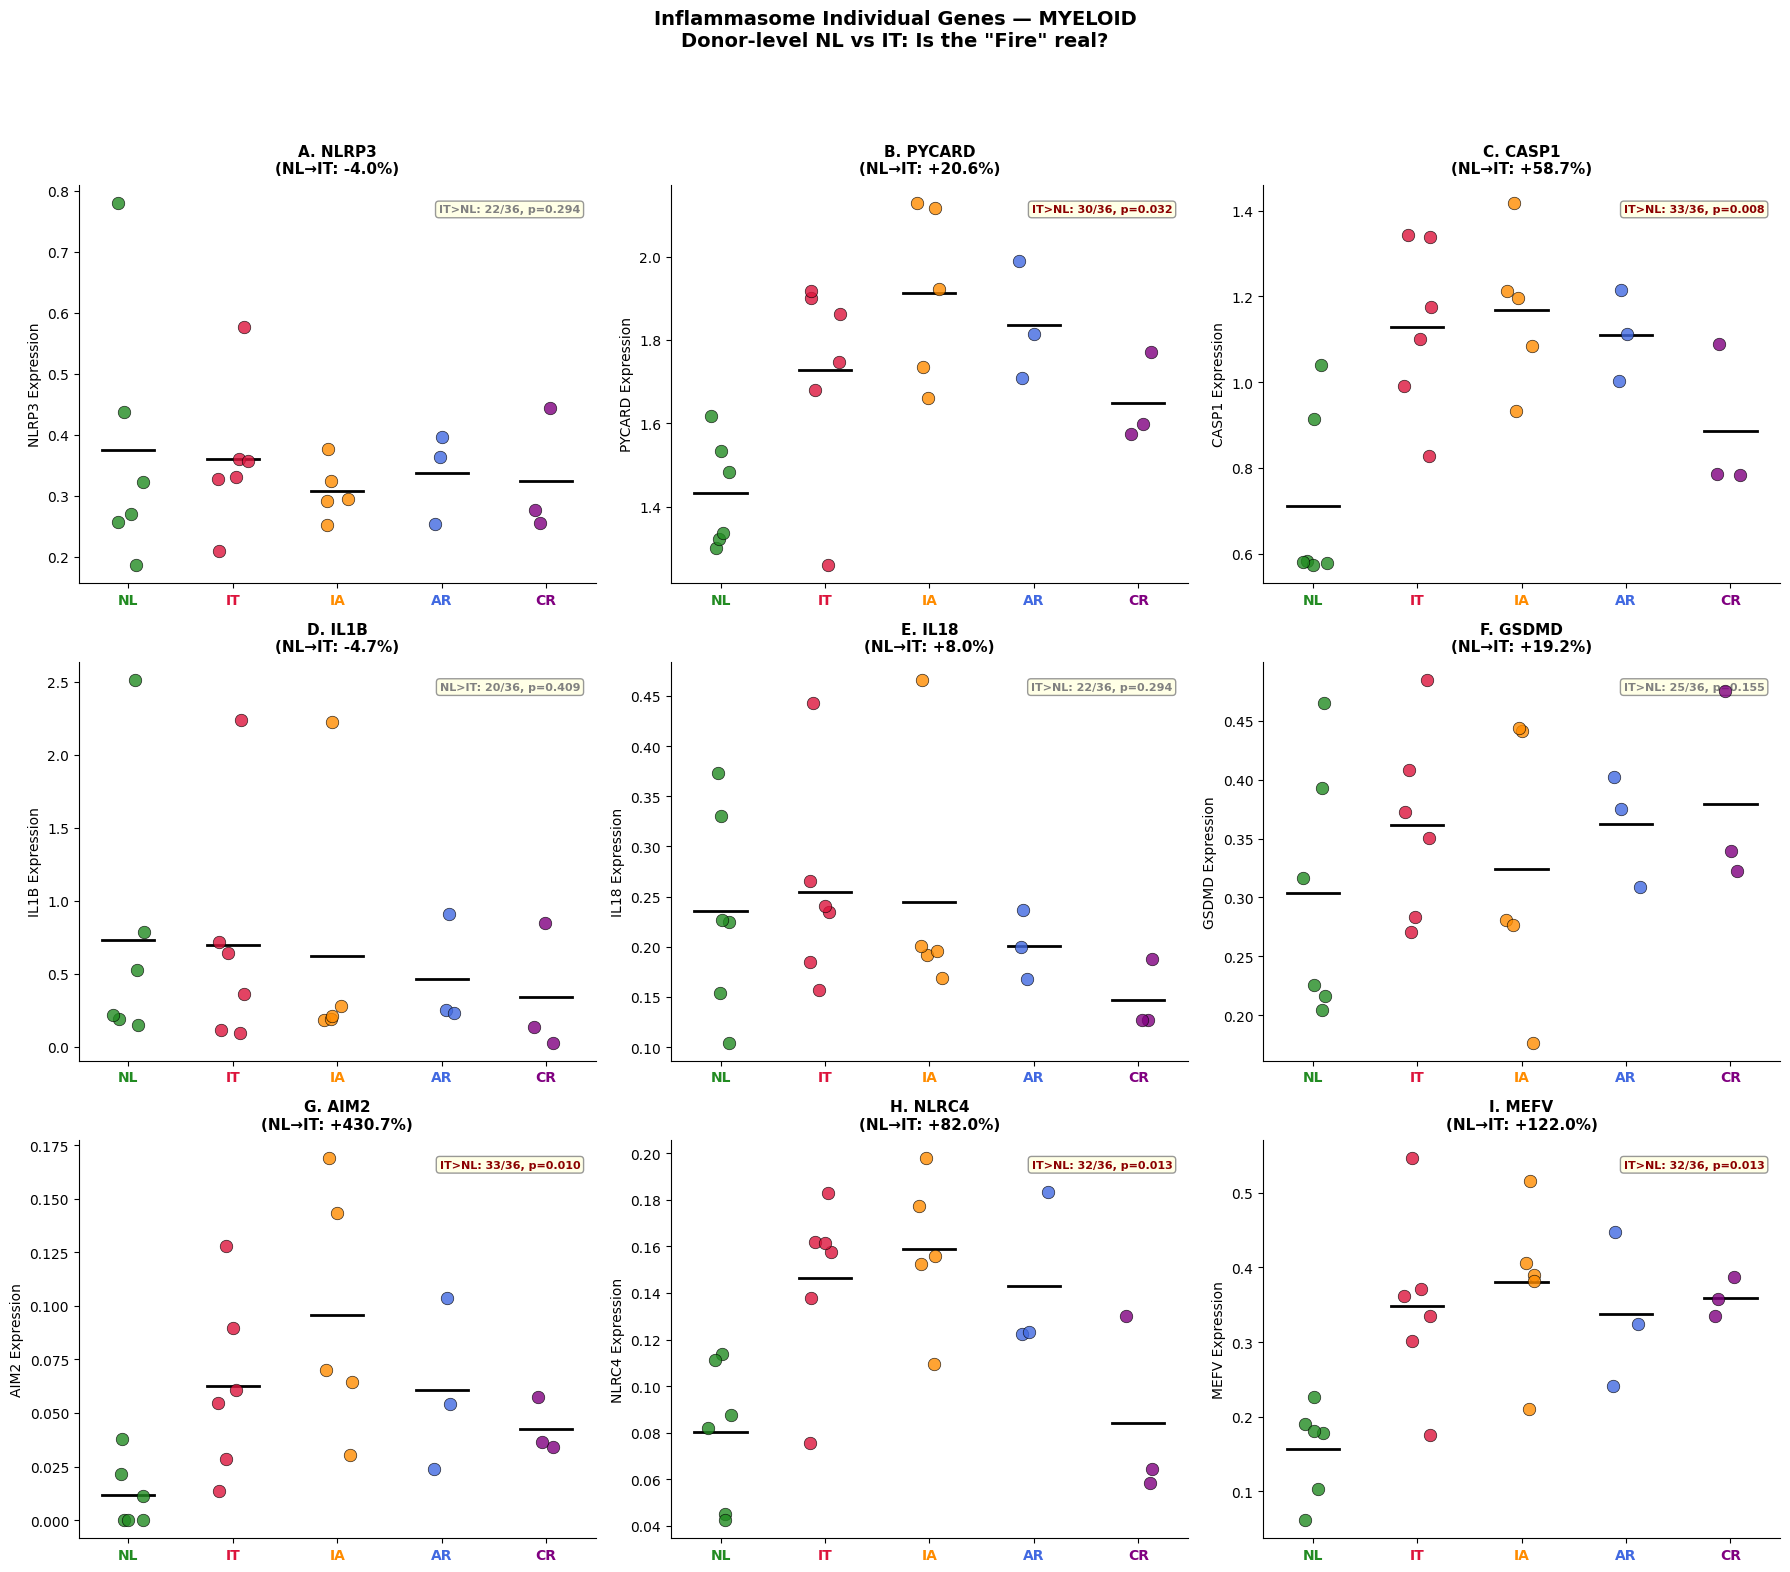


Saved: Myeloid Inflammasome Genes


In [17]:
# ============================================================
# PART 2: 9 Inflammasome genes — Myeloid, donor-level NL vs IT
# ============================================================
print("\n" + "="*80)
print("PART 2: INFLAMMASOME INDIVIDUAL GENES — MYELOID NL vs IT")
print("="*80)

INFLAMMASOME_GENES = ['NLRP3', 'PYCARD', 'CASP1', 'IL1B', 'IL18',
                       'GSDMD', 'AIM2', 'NLRC4', 'MEFV']

fig2, axes2 = plt.subplots(3, 3, figsize=(18, 16))
fig2.suptitle('Inflammasome Individual Genes — MYELOID\n'
              'Donor-level NL vs IT: Is the "Fire" real?',
              fontsize=14, fontweight='bold', y=0.98)

print(f"\n{'Gene':<10s} {'NL mean':>10s} {'IT mean':>10s} {'Change':>10s} "
      f"{'Direction':>12s} {'Consist':>10s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 80)

inflamm_results = {}
for idx, gene in enumerate(INFLAMMASOME_GENES):
    ax = axes2[idx // 3, idx % 3]
    donor_df = get_donor_means(adata_myeloid, gene)

    if donor_df is None:
        print(f"  {gene}: NOT FOUND in dataset")
        ax.text(0.5, 0.5, f'{gene}\nNot found', transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        continue

    result = donor_test(donor_df, 'NL', 'IT')
    inflamm_results[gene] = result

    sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""
    print(f"  {gene:<10s} {result['va'].mean():>10.4f} {result['vb'].mean():>10.4f} "
          f"{result['change']:>+9.1f}% {result['direction']:>12s} "
          f"{result['consist']}/{result['total']} {result['p']:>10.3f}{sig}")

    # Plot all 5 stages
    plot_donor_dots(ax, donor_df,
                    f'{chr(65+idx)}. {gene}\n(NL→IT: {result["change"]:+.1f}%)',
                    f'{gene} Expression')

    # Add stat annotation
    pcolor = 'darkred' if result['p'] < 0.05 else 'darkblue' if result['p'] < 0.1 else 'grey'
    label = f'{result["direction"]}: {result["consist"]}/{result["total"]}, p={result["p"]:.3f}'
    ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=8,
            ha='right', va='top', color=pcolor, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      alpha=0.8, edgecolor='grey'))

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig2.savefig(os.path.join(SAVE_DIR, 'SupFig_Myeloid_Inflammasome_Genes.png'),
             dpi=300, bbox_inches='tight', facecolor='white')
fig2.savefig(os.path.join(SAVE_DIR, 'SupFig_Myeloid_Inflammasome_Genes.pdf'),
             bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Myeloid Inflammasome Genes")


PART 4: BRAKE GENES — MYELOID NL vs IT

Gene          NL mean    IT mean     Change    Direction    Consist    p-value   Sig
--------------------------------------------------------------------------------
  TNFAIP3        0.3939     0.4709     +19.6%        IT>NL 21/36      0.350
  IDO1           0.0536     0.0965     +80.1%        IT>NL 20/36      0.409
  LGALS9         0.6694     1.1703     +74.8%        IT>NL 36/36      0.001 **
  IL1RN          0.3365     0.3339      -0.8%        IT>NL 19/36      0.469
  TGFB1          0.8116     1.2373     +52.4%        IT>NL 33/36      0.008 **


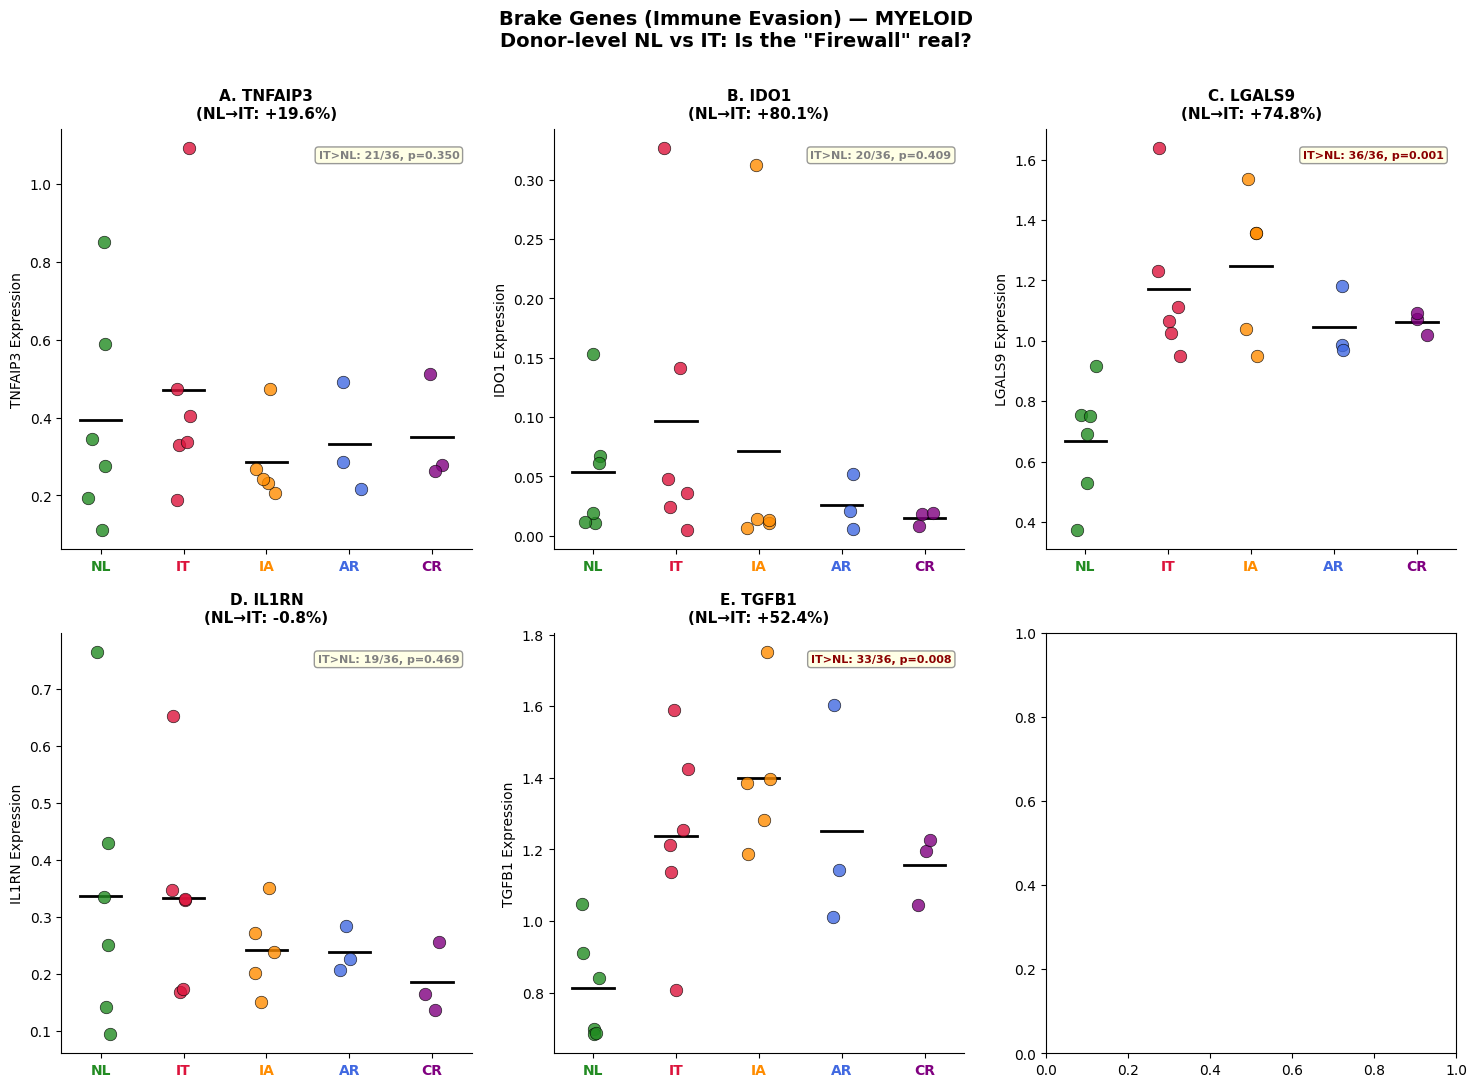

In [18]:
# ============================================================
# PART 3 & 4: Brake genes (immune evasion) — Myeloid, donor-level
# ============================================================
print("\n" + "="*80)
print("PART 4: BRAKE GENES — MYELOID NL vs IT")
print("="*80)

BRAKE_GENES = ['TNFAIP3', 'IDO1', 'LGALS9', 'IL1RN', 'TGFB1']

fig4, axes4 = plt.subplots(2, 3, figsize=(18, 12))
fig4.suptitle('Brake Genes (Immune Evasion) — MYELOID\n'
              'Donor-level NL vs IT: Is the "Firewall" real?',
              fontsize=14, fontweight='bold', y=0.98)

print(f"\n{'Gene':<10s} {'NL mean':>10s} {'IT mean':>10s} {'Change':>10s} "
      f"{'Direction':>12s} {'Consist':>10s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 80)

brake_results = {}
for idx, gene in enumerate(BRAKE_GENES):
    ax = axes4[idx // 3, idx % 3]
    donor_df = get_donor_means(adata_myeloid, gene)

    if donor_df is None:
        print(f"  {gene}: NOT FOUND")
        ax.text(0.5, 0.5, f'{gene}\nNot found', transform=ax.transAxes,
                ha='center', va='center', fontsize=12)
        continue

    result = donor_test(donor_df, 'NL', 'IT')
    brake_results[gene] = result

    sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""
    print(f"  {gene:<10s} {result['va'].mean():>10.4f} {result['vb'].mean():>10.4f} "
          f"{result['change']:>+9.1f}% {result['direction']:>12s} "
          f"{result['consist']}/{result['total']} {result['p']:>10.3f}{sig}")

    plot_donor_dots(ax, donor_df,
                    f'{chr(65+idx)}. {gene}\n(NL→IT: {result["change"]:+.1f}%)',
                    f'{gene} Expression')

    pcolor = 'darkred' if result['p'] < 0.05 else 'darkblue' if result['p'] < 0.1 else 'grey'
    label = f'{result["direction"]}: {result["consist"]}/{result["total"]}, p={result["p"]:.3f}'
    ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=8,
            ha='right', va='top', color=pcolor, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                      alpha=0.8, edgecolor='grey'))

# Empty last panel — use for IL1B/IL1RN ratio
ax_ratio = axes4[1, 2]

In [19]:
# ============================================================
# PART 5: IL1B/IL1RN RATIO — Myeloid, donor-level
# ============================================================
print("\n" + "="*80)
print("PART 5: IL1B/IL1RN RATIO — MYELOID, DONOR-LEVEL")
print("="*80)

# Get per-cell IL1B and IL1RN, then compute donor-level ratio
if 'IL1B' in adata_myeloid.var_names and 'IL1RN' in adata_myeloid.var_names:
    if sp.issparse(adata_myeloid.X):
        il1b_expr = adata_myeloid[:, 'IL1B'].X.toarray().flatten()
        il1rn_expr = adata_myeloid[:, 'IL1RN'].X.toarray().flatten()
    else:
        il1b_expr = adata_myeloid[:, 'IL1B'].X.flatten()
        il1rn_expr = adata_myeloid[:, 'IL1RN'].X.flatten()

    ratio_df = pd.DataFrame({
        'IL1B': il1b_expr,
        'IL1RN': il1rn_expr,
        'Stage': adata_myeloid.obs['Stage'].astype(str).values,
        'donor_id': adata_myeloid.obs['donor_id'].astype(str).values
    })

    # Donor-level means
    donor_ratio = ratio_df.groupby(['donor_id', 'Stage']).agg(
        IL1B_mean=('IL1B', 'mean'),
        IL1RN_mean=('IL1RN', 'mean')
    ).reset_index()

    # Compute ratio (add small epsilon to avoid div by zero)
    eps = 1e-6
    donor_ratio['ratio'] = donor_ratio['IL1B_mean'] / (donor_ratio['IL1RN_mean'] + eps)
    donor_ratio['expression'] = donor_ratio['ratio']  # for plotting function

    print("\nDonor-level IL1B/IL1RN ratio by stage:")
    for stage in STAGE_ORDER:
        sd = donor_ratio[donor_ratio['Stage'] == stage]
        if len(sd) > 0:
            print(f"  {stage}: mean ratio = {sd['ratio'].mean():.3f} "
                  f"(IL1B={sd['IL1B_mean'].mean():.4f}, IL1RN={sd['IL1RN_mean'].mean():.4f}), "
                  f"n={len(sd)} donors")

    # Test NL vs IT
    ratio_result = donor_test(donor_ratio, 'NL', 'IT')
    sig = " **" if ratio_result['p'] < 0.05 else " *" if ratio_result['p'] < 0.1 else ""
    print(f"\n  NL→IT ratio: {ratio_result['change']:+.1f}%, "
          f"{ratio_result['direction']}: {ratio_result['consist']}/{ratio_result['total']}, "
          f"p={ratio_result['p']:.3f}{sig}")

    # Also test IT vs IA (brake release?)
    ratio_it_ia = donor_test(donor_ratio, 'IT', 'IA')
    sig2 = " **" if ratio_it_ia['p'] < 0.05 else " *" if ratio_it_ia['p'] < 0.1 else ""
    print(f"  IT→IA ratio: {ratio_it_ia['change']:+.1f}%, "
          f"{ratio_it_ia['direction']}: {ratio_it_ia['consist']}/{ratio_it_ia['total']}, "
          f"p={ratio_it_ia['p']:.3f}{sig2}")

    # Plot ratio
    plot_donor_dots(ax_ratio, donor_ratio,
                    f'F. IL1B/IL1RN Ratio\n(NL→IT: {ratio_result["change"]:+.1f}%)',
                    'IL1B/IL1RN Ratio')
    pcolor = 'darkred' if ratio_result['p'] < 0.05 else 'darkblue' if ratio_result['p'] < 0.1 else 'grey'
    label = f'{ratio_result["direction"]}: {ratio_result["consist"]}/{ratio_result["total"]}, p={ratio_result["p"]:.3f}'
    ax_ratio.text(0.97, 0.95, label, transform=ax_ratio.transAxes, fontsize=8,
                  ha='right', va='top', color=pcolor, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                            alpha=0.8, edgecolor='grey'))

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig4.savefig(os.path.join(SAVE_DIR, 'SupFig_Myeloid_BrakeGenes_IL1Bratio.png'),
             dpi=300, bbox_inches='tight', facecolor='white')
fig4.savefig(os.path.join(SAVE_DIR, 'SupFig_Myeloid_BrakeGenes_IL1Bratio.pdf'),
             bbox_inches='tight', facecolor='white')
plt.show()
print("\nSaved: Myeloid Brake Genes + IL1B/IL1RN ratio")



PART 5: IL1B/IL1RN RATIO — MYELOID, DONOR-LEVEL

Donor-level IL1B/IL1RN ratio by stage:
  NL: mean ratio = 1.752 (IL1B=0.7305, IL1RN=0.3365), n=6 donors
  IT: mean ratio = 1.636 (IL1B=0.6965, IL1RN=0.3339), n=6 donors
  IA: mean ratio = 2.140 (IL1B=0.6193, IL1RN=0.2431), n=5 donors
  AR: mean ratio = 1.822 (IL1B=0.4665, IL1RN=0.2393), n=3 donors
  CR: mean ratio = 1.458 (IL1B=0.3393, IL1RN=0.1860), n=3 donors

  NL→IT ratio: -6.6%, NL>IT: 19/36, p=0.469
  IT→IA ratio: +30.8%, IA>IT: 15/30, p=0.535


<Figure size 640x480 with 0 Axes>


Saved: Myeloid Brake Genes + IL1B/IL1RN ratio



PART 6: INFLAMMASOME KEY GENES — CROSS-LINEAGE NL vs IT
       Is the Fire truly Myeloid-specific?

--- NLRP3 CROSS-LINEAGE: NL vs IT ---
  NK        : NL=0.0153 IT=0.0107 (-30.4%) | NL>IT: 27/36, p=0.090 *
  CD8_T     : NL=0.0334 IT=0.0176 (-47.2%) | NL>IT: 25/36, p=0.155
  CD4_T     : NL=0.0297 IT=0.0172 (-41.9%) | NL>IT: 26/36, p=0.120
  Myeloid   : NL=0.3758 IT=0.3605 (-4.0%) | IT>NL: 22/36, p=0.294
  B         : NL=0.0000 IT=0.0020 (+0.0%) | IT>NL: 24/36, p=0.014 **
  PlasmaB   : NL=0.0000 IT=0.0164 (+0.0%) | IT>NL: 24/36, p=0.014 **


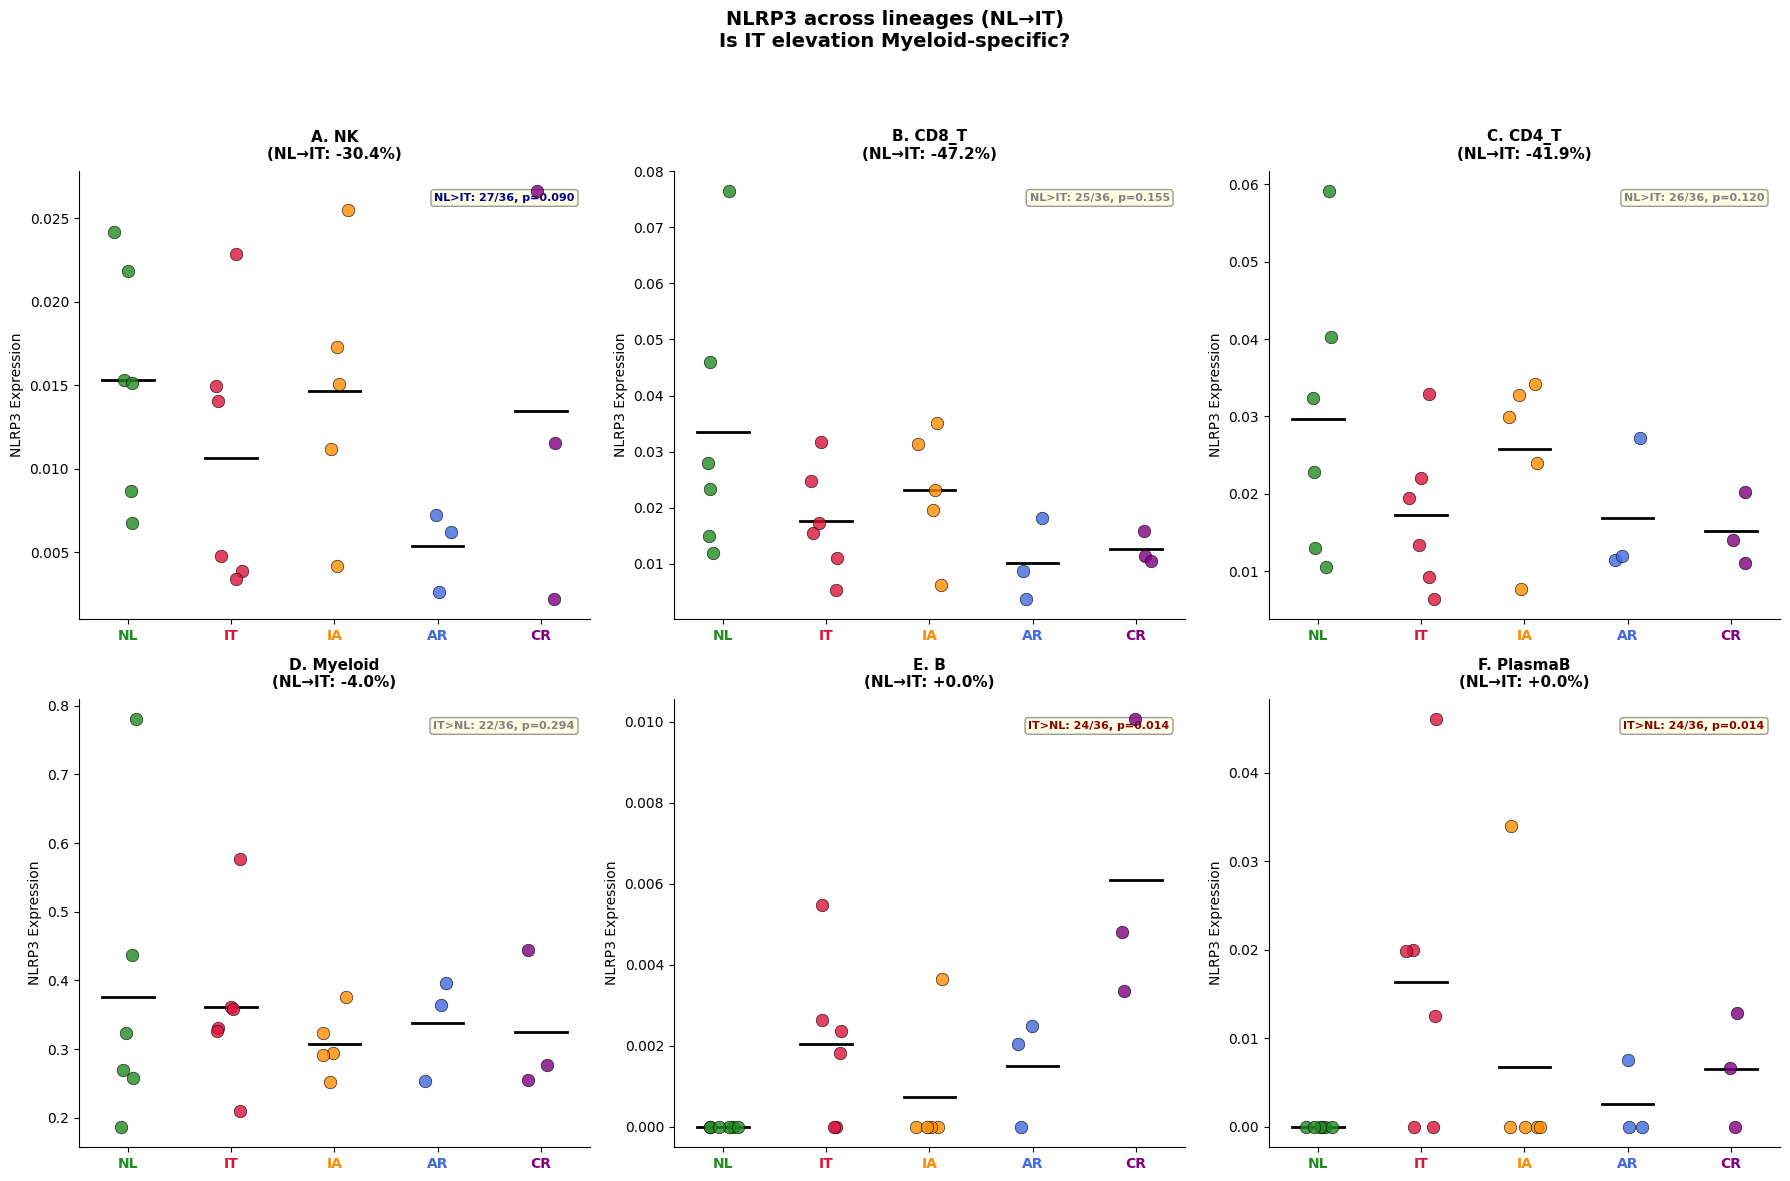

Saved: NLRP3 cross-lineage NL vs IT

--- IL1B CROSS-LINEAGE: NL vs IT ---
  NK        : NL=0.0017 IT=0.0113 (+563.2%) | IT>NL: 23/36, p=0.188
  CD8_T     : NL=0.0083 IT=0.0129 (+55.4%) | IT>NL: 26/36, p=0.071 *
  CD4_T     : NL=0.0039 IT=0.0154 (+294.2%) | IT>NL: 24/36, p=0.127
  Myeloid   : NL=0.7305 IT=0.6965 (-4.7%) | NL>IT: 20/36, p=0.409
  B         : NL=0.0000 IT=0.0088 (+0.0%) | IT>NL: 12/36, p=0.088 *
  PlasmaB   : NL=0.0014 IT=0.0164 (+1062.9%) | NL>IT: 10/36, p=0.376


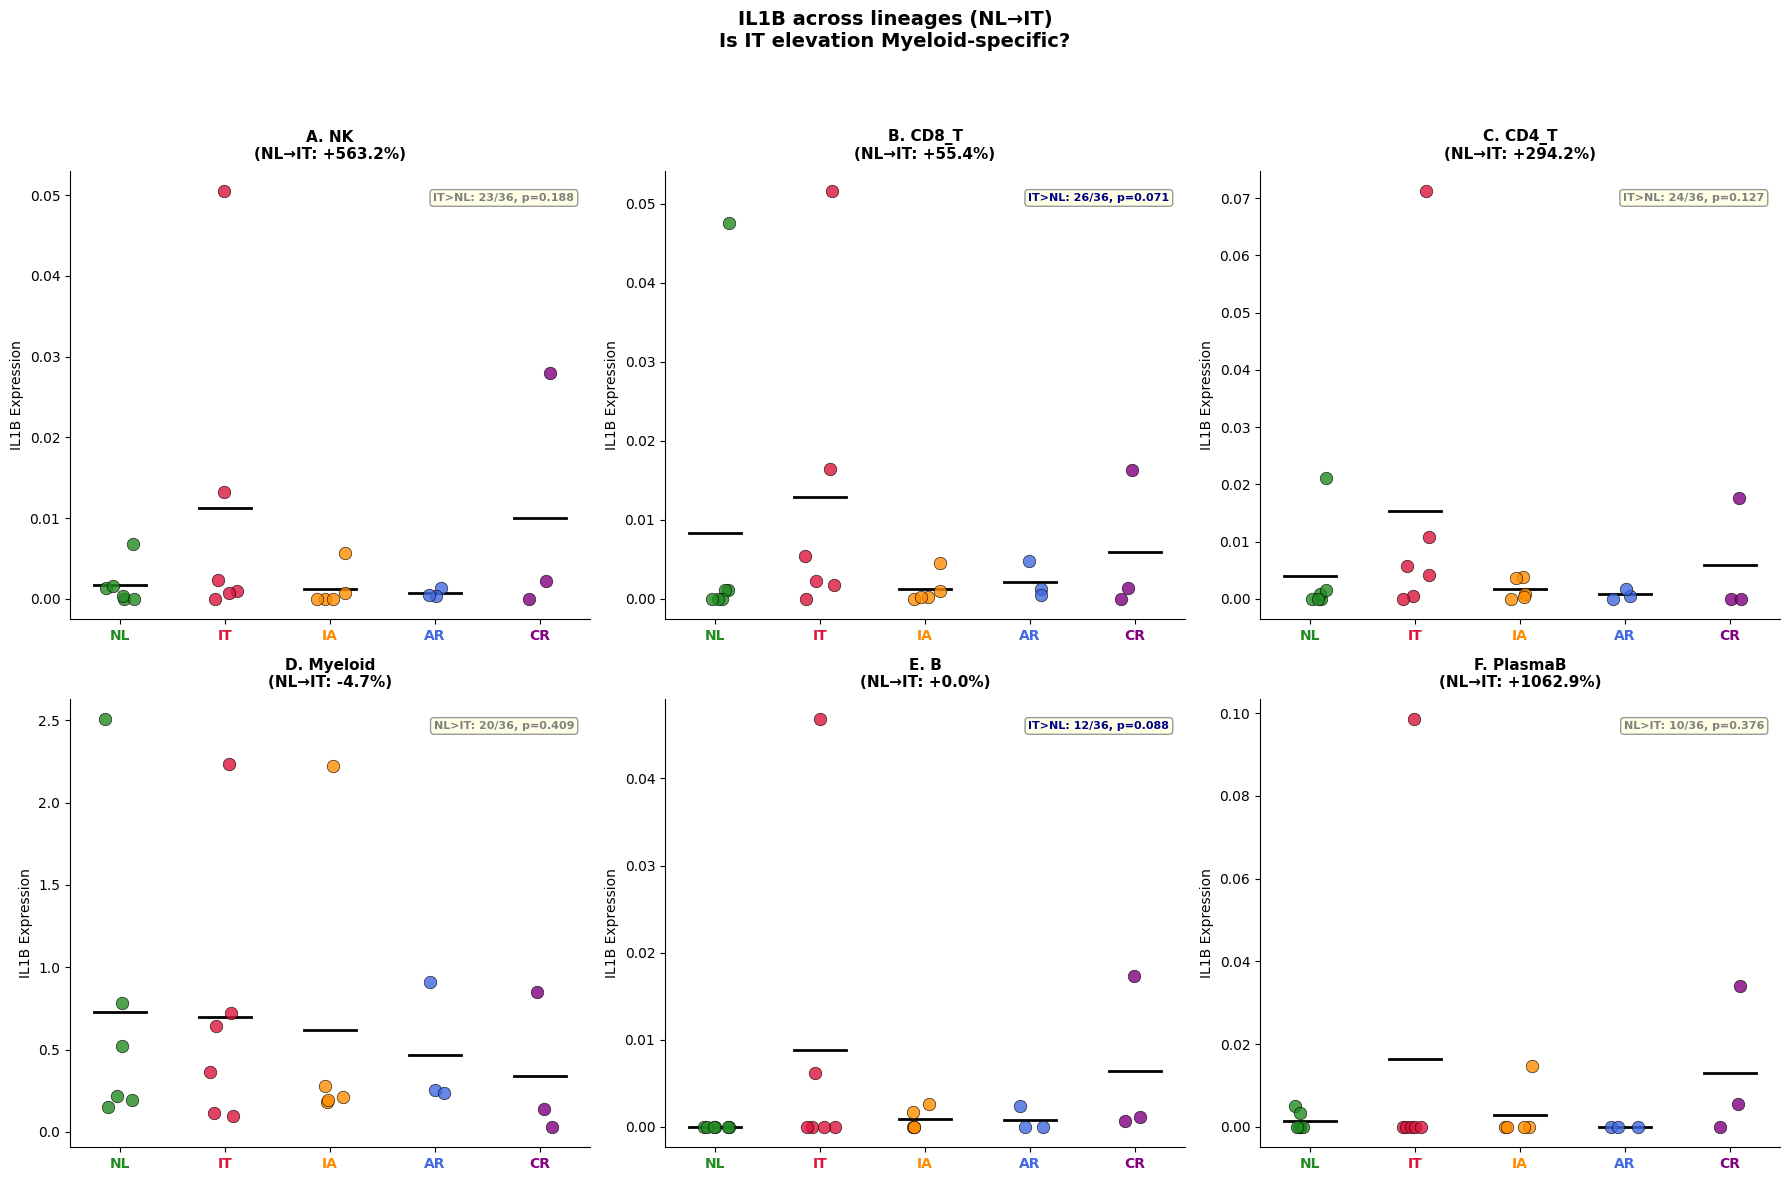

Saved: IL1B cross-lineage NL vs IT

--- CASP1 CROSS-LINEAGE: NL vs IT ---
  NK        : NL=0.3506 IT=0.4219 (+20.3%) | IT>NL: 23/36, p=0.242
  CD8_T     : NL=0.3282 IT=0.3482 (+6.1%) | IT>NL: 18/36, p=0.531
  CD4_T     : NL=0.3161 IT=0.3561 (+12.7%) | IT>NL: 25/36, p=0.155
  Myeloid   : NL=0.7117 IT=1.1295 (+58.7%) | IT>NL: 33/36, p=0.008 **
  B         : NL=0.1782 IT=0.2377 (+33.4%) | IT>NL: 26/36, p=0.120
  PlasmaB   : NL=0.0506 IT=0.0759 (+50.0%) | IT>NL: 26/36, p=0.114


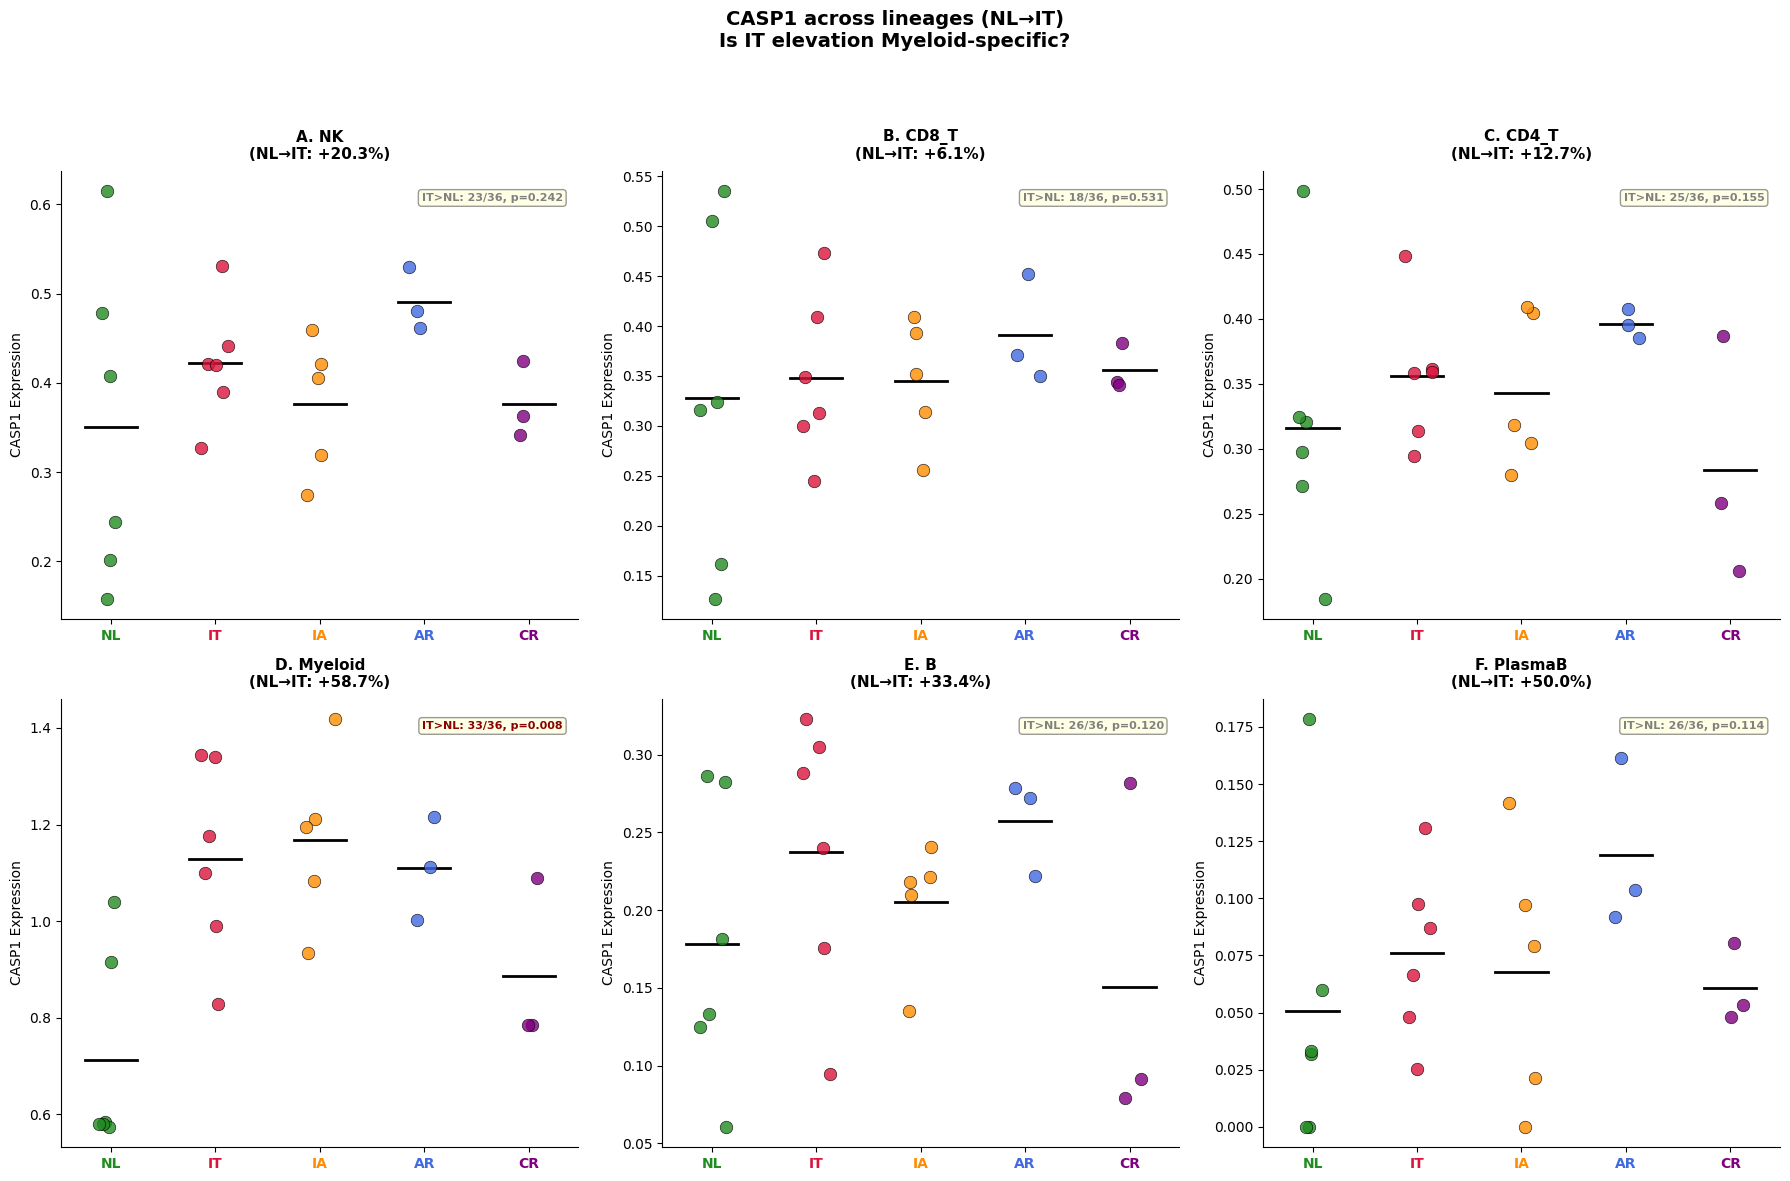

Saved: CASP1 cross-lineage NL vs IT

--- GSDMD CROSS-LINEAGE: NL vs IT ---
  NK        : NL=0.2786 IT=0.3149 (+13.0%) | IT>NL: 24/36, p=0.197
  CD8_T     : NL=0.2816 IT=0.2973 (+5.6%) | IT>NL: 22/36, p=0.294
  CD4_T     : NL=0.2884 IT=0.3095 (+7.3%) | IT>NL: 22/36, p=0.294
  Myeloid   : NL=0.3036 IT=0.3618 (+19.2%) | IT>NL: 25/36, p=0.155
  B         : NL=0.2222 IT=0.2436 (+9.6%) | IT>NL: 18/36, p=0.531
  PlasmaB   : NL=0.1227 IT=0.2253 (+83.7%) | IT>NL: 29/36, p=0.047 **


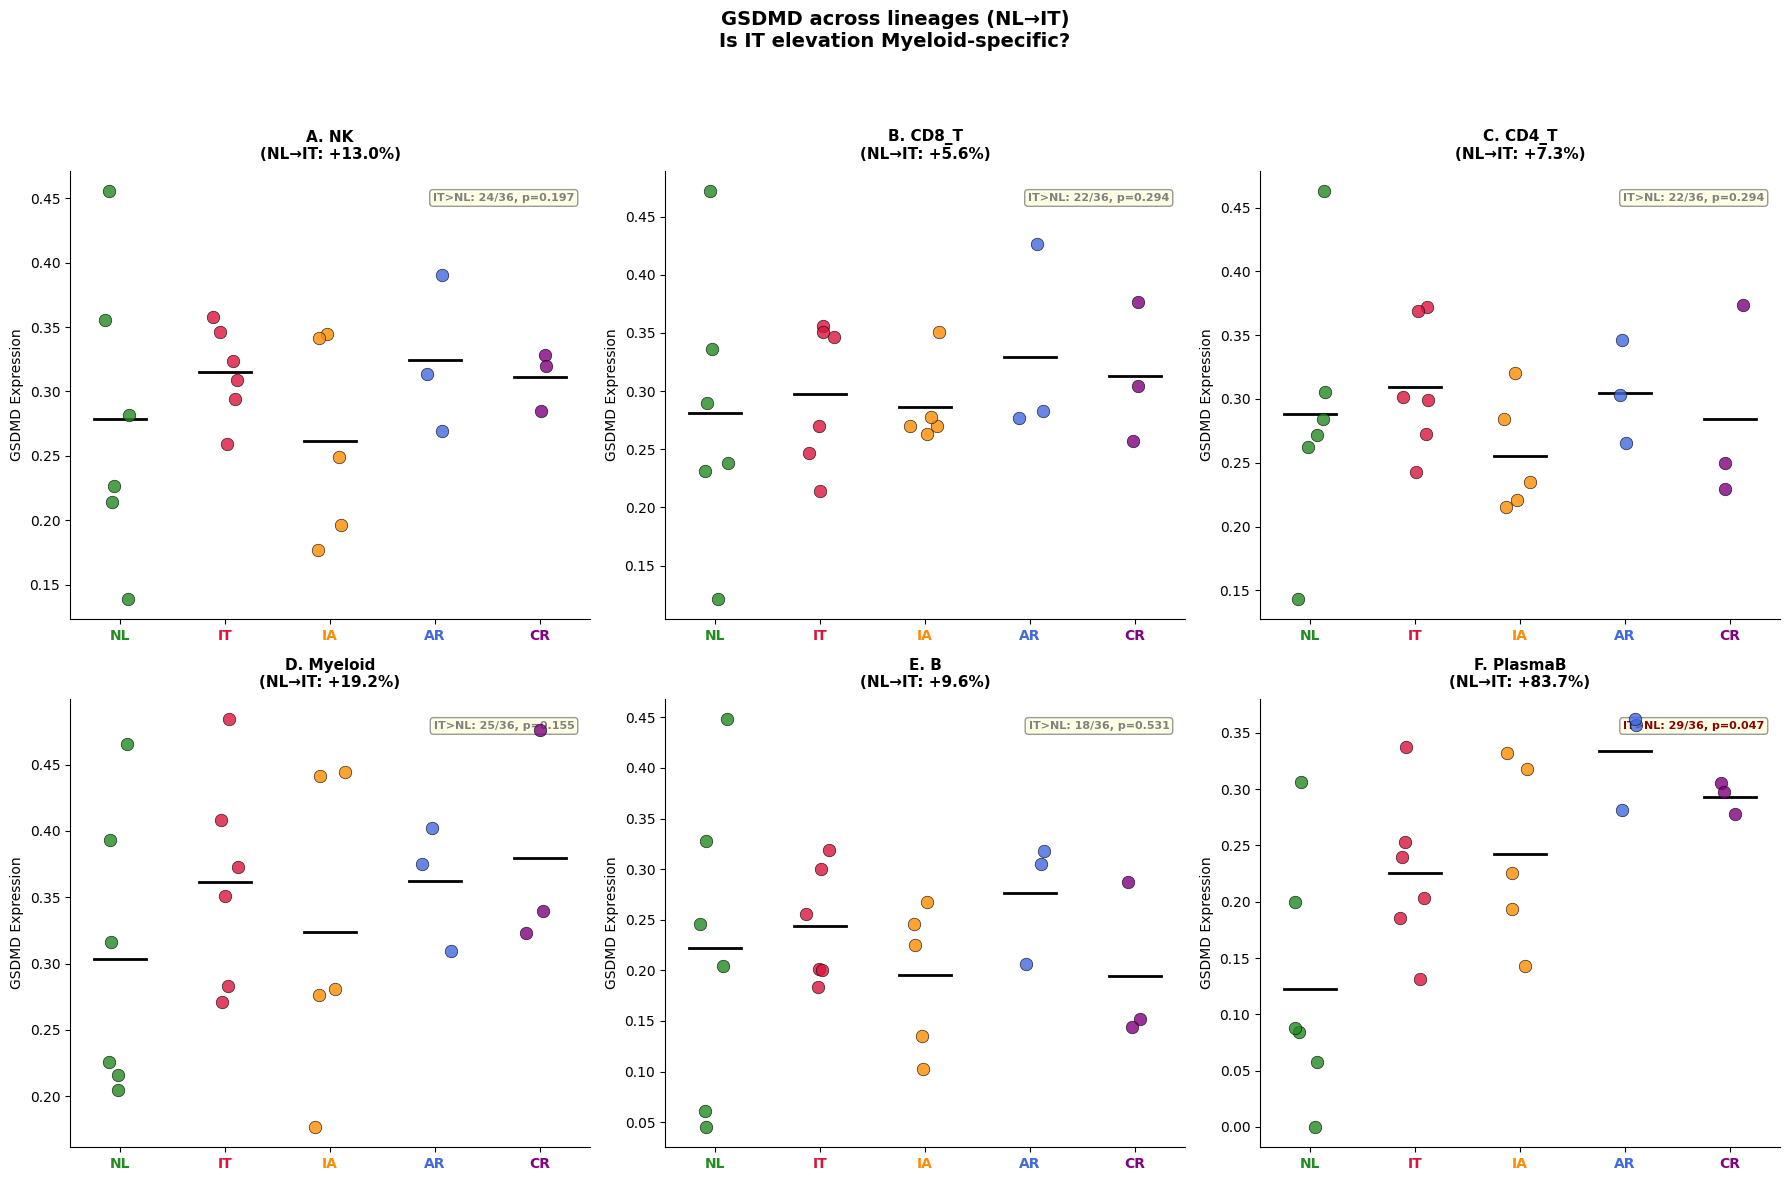

Saved: GSDMD cross-lineage NL vs IT


In [20]:
# ============================================================
# PART 6: INFLAMMASOME CROSS-LINEAGE — Is it Myeloid-specific?
# ============================================================
print("\n" + "="*80)
print("PART 6: INFLAMMASOME KEY GENES — CROSS-LINEAGE NL vs IT")
print("       Is the Fire truly Myeloid-specific?")
print("="*80)

# Test key inflammasome genes across all lineages
KEY_FIRE_GENES = ['NLRP3', 'IL1B', 'CASP1', 'GSDMD']

for gene in KEY_FIRE_GENES:
    fig6, axes6 = plt.subplots(2, 3, figsize=(18, 12))
    fig6.suptitle(f'{gene} across lineages (NL→IT)\n'
                  f'Is IT elevation Myeloid-specific?',
                  fontsize=14, fontweight='bold', y=0.98)

    print(f"\n--- {gene} CROSS-LINEAGE: NL vs IT ---")

    for idx, lineage in enumerate(LINEAGES):
        ax = axes6[idx // 3, idx % 3]
        lin_mask = adata.obs['major_lineage'] == lineage
        adata_lin = adata[lin_mask]

        donor_df = get_donor_means(adata_lin, gene)
        if donor_df is None:
            print(f"  {lineage:10s}: {gene} not found")
            ax.text(0.5, 0.5, 'Gene not found', transform=ax.transAxes, ha='center')
            continue

        result = donor_test(donor_df, 'NL', 'IT')
        sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""

        print(f"  {lineage:10s}: NL={result['va'].mean():.4f} IT={result['vb'].mean():.4f} "
              f"({result['change']:+.1f}%) | {result['direction']}: "
              f"{result['consist']}/{result['total']}, p={result['p']:.3f}{sig}")

        plot_donor_dots(ax, donor_df,
                        f'{chr(65+idx)}. {lineage}\n(NL→IT: {result["change"]:+.1f}%)',
                        f'{gene} Expression')

        pcolor = 'darkred' if result['p'] < 0.05 else 'darkblue' if result['p'] < 0.1 else 'grey'
        label = f'{result["direction"]}: {result["consist"]}/{result["total"]}, p={result["p"]:.3f}'
        ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=8,
                ha='right', va='top', color=pcolor, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          alpha=0.8, edgecolor='grey'))

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    fig6.savefig(os.path.join(SAVE_DIR, f'SupFig_{gene}_CrossLineage_NLvsIT.png'),
                 dpi=300, bbox_inches='tight', facecolor='white')
    fig6.savefig(os.path.join(SAVE_DIR, f'SupFig_{gene}_CrossLineage_NLvsIT.pdf'),
                 bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {gene} cross-lineage NL vs IT")


PART 7: BRAKE GENES — CROSS-LINEAGE NL vs IT
       Is the Firewall Myeloid-specific?

--- TNFAIP3 CROSS-LINEAGE: NL vs IT ---
  NK        : NL=1.2755 IT=0.9458 (-25.8%) | NL>IT: 30/36, p=0.032 **
  CD8_T     : NL=1.7371 IT=1.2706 (-26.9%) | NL>IT: 30/36, p=0.032 **
  CD4_T     : NL=1.4631 IT=1.1083 (-24.2%) | NL>IT: 27/36, p=0.090 *
  Myeloid   : NL=0.3939 IT=0.4709 (+19.6%) | IT>NL: 21/36, p=0.350
  B         : NL=0.1802 IT=0.1574 (-12.7%) | NL>IT: 26/36, p=0.120
  PlasmaB   : NL=0.2690 IT=0.3107 (+15.5%) | IT>NL: 22/36, p=0.294


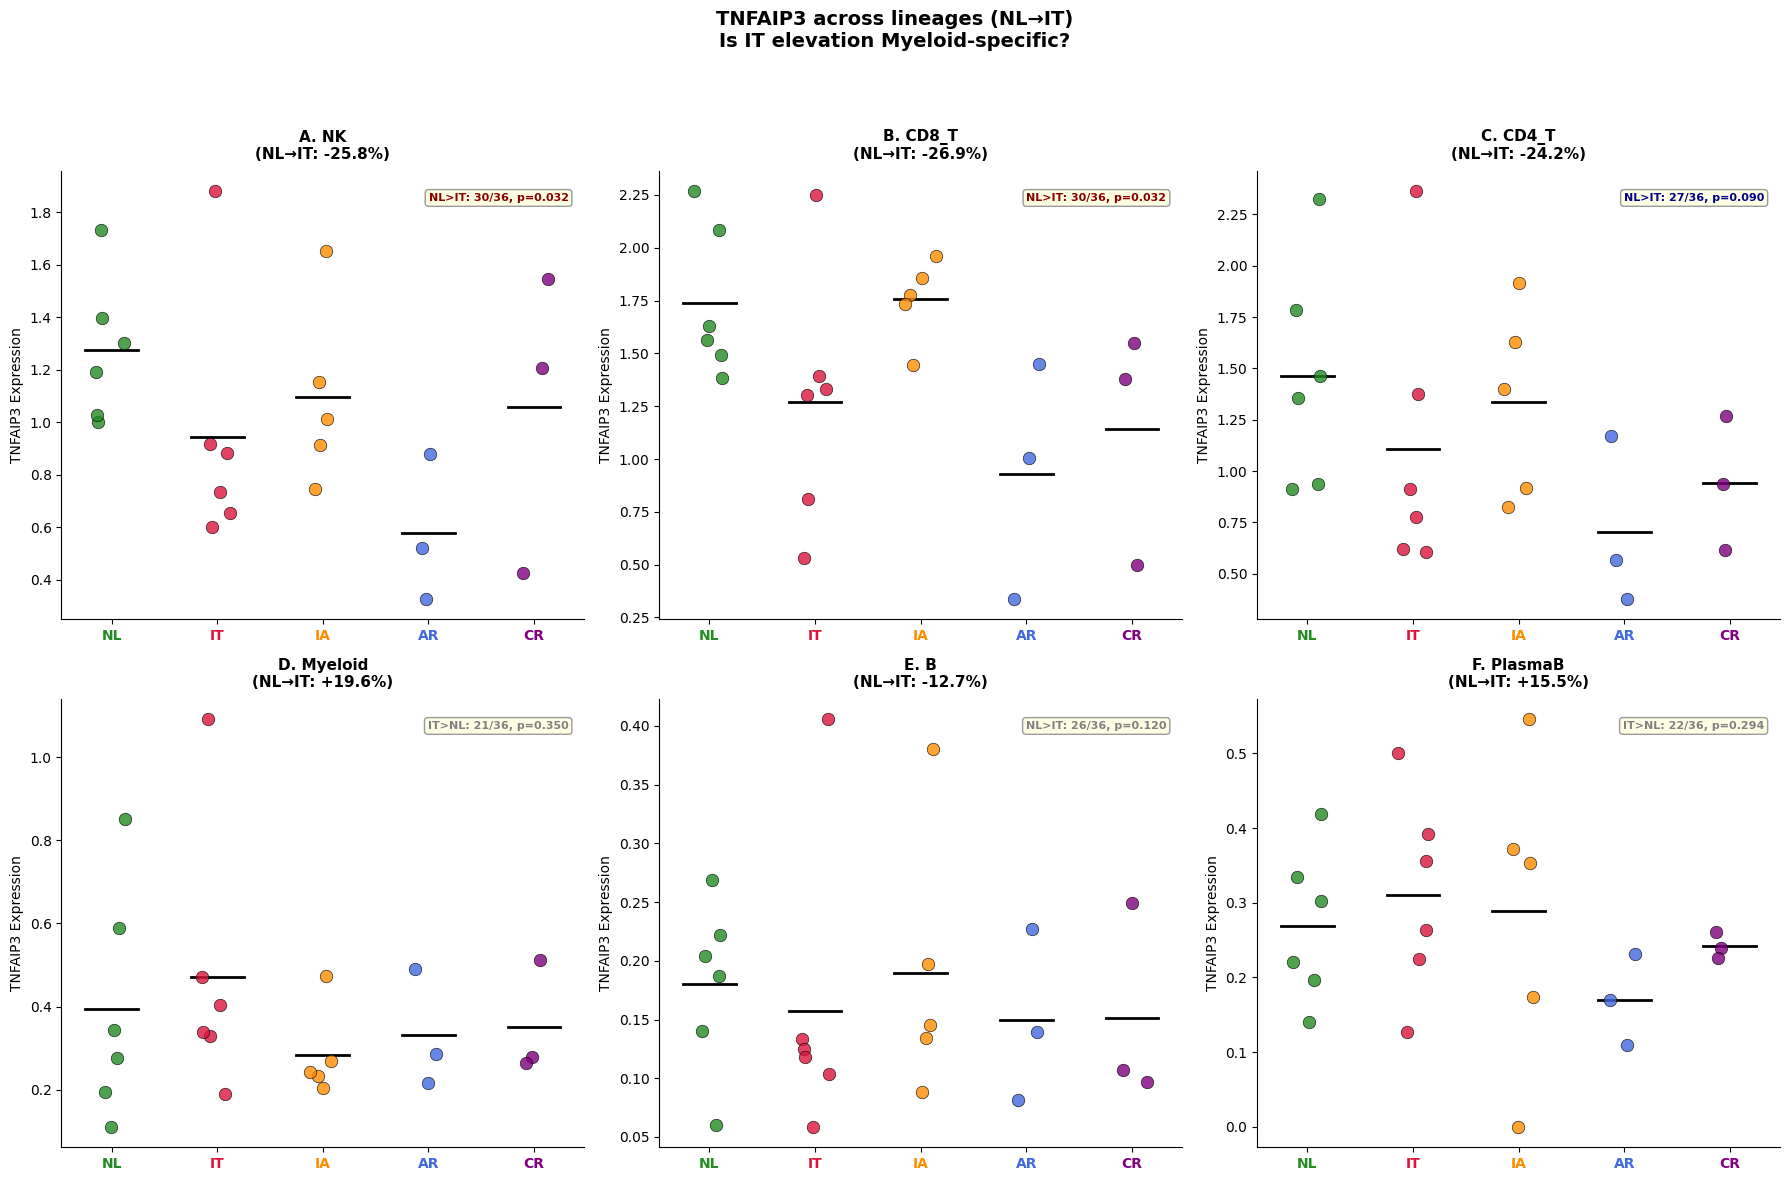

Saved: TNFAIP3 cross-lineage NL vs IT

--- IDO1 CROSS-LINEAGE: NL vs IT ---
  NK        : NL=0.0002 IT=0.0018 (+721.6%) | IT>NL: 17/36, p=0.126
  CD8_T     : NL=0.0001 IT=0.0011 (+1633.1%) | IT>NL: 12/36, p=0.231
  CD4_T     : NL=0.0003 IT=0.0010 (+203.5%) | IT>NL: 21/36, p=0.133
  Myeloid   : NL=0.0536 IT=0.0965 (+80.1%) | IT>NL: 20/36, p=0.409
  B         : NL=0.0018 IT=0.0028 (+55.8%) | IT>NL: 20/36, p=0.174
  PlasmaB   : NL=0.0215 IT=0.0000 (-100.0%) | NL>IT: 18/36, p=0.037 **


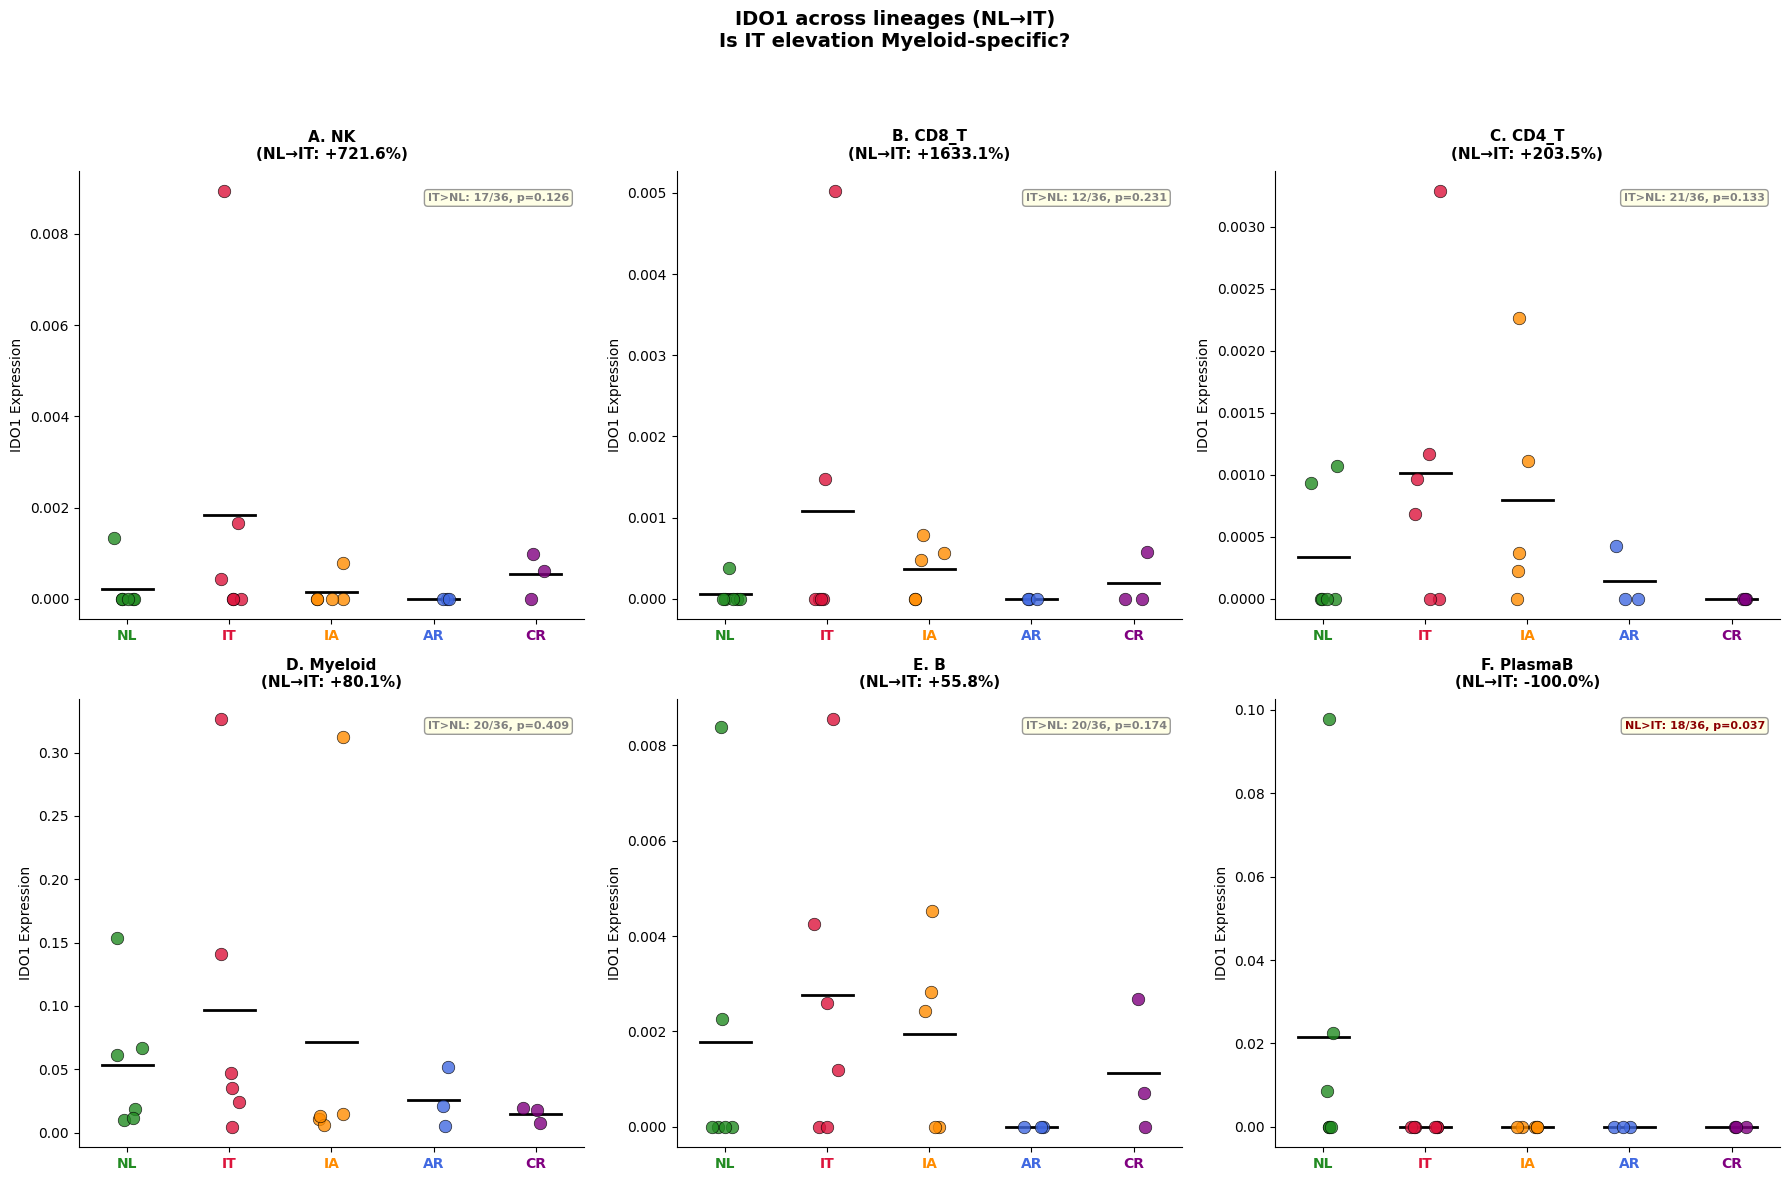

Saved: IDO1 cross-lineage NL vs IT

--- LGALS9 CROSS-LINEAGE: NL vs IT ---
  NK        : NL=0.1055 IT=0.1506 (+42.8%) | IT>NL: 31/36, p=0.021 **
  CD8_T     : NL=0.0712 IT=0.0878 (+23.4%) | IT>NL: 24/36, p=0.197
  CD4_T     : NL=0.0821 IT=0.1405 (+71.2%) | IT>NL: 29/36, p=0.047 **
  Myeloid   : NL=0.6694 IT=1.1703 (+74.8%) | IT>NL: 36/36, p=0.001 **
  B         : NL=0.2453 IT=0.3270 (+33.3%) | IT>NL: 27/36, p=0.090 *
  PlasmaB   : NL=0.0349 IT=0.2178 (+524.7%) | IT>NL: 32/36, p=0.015 **


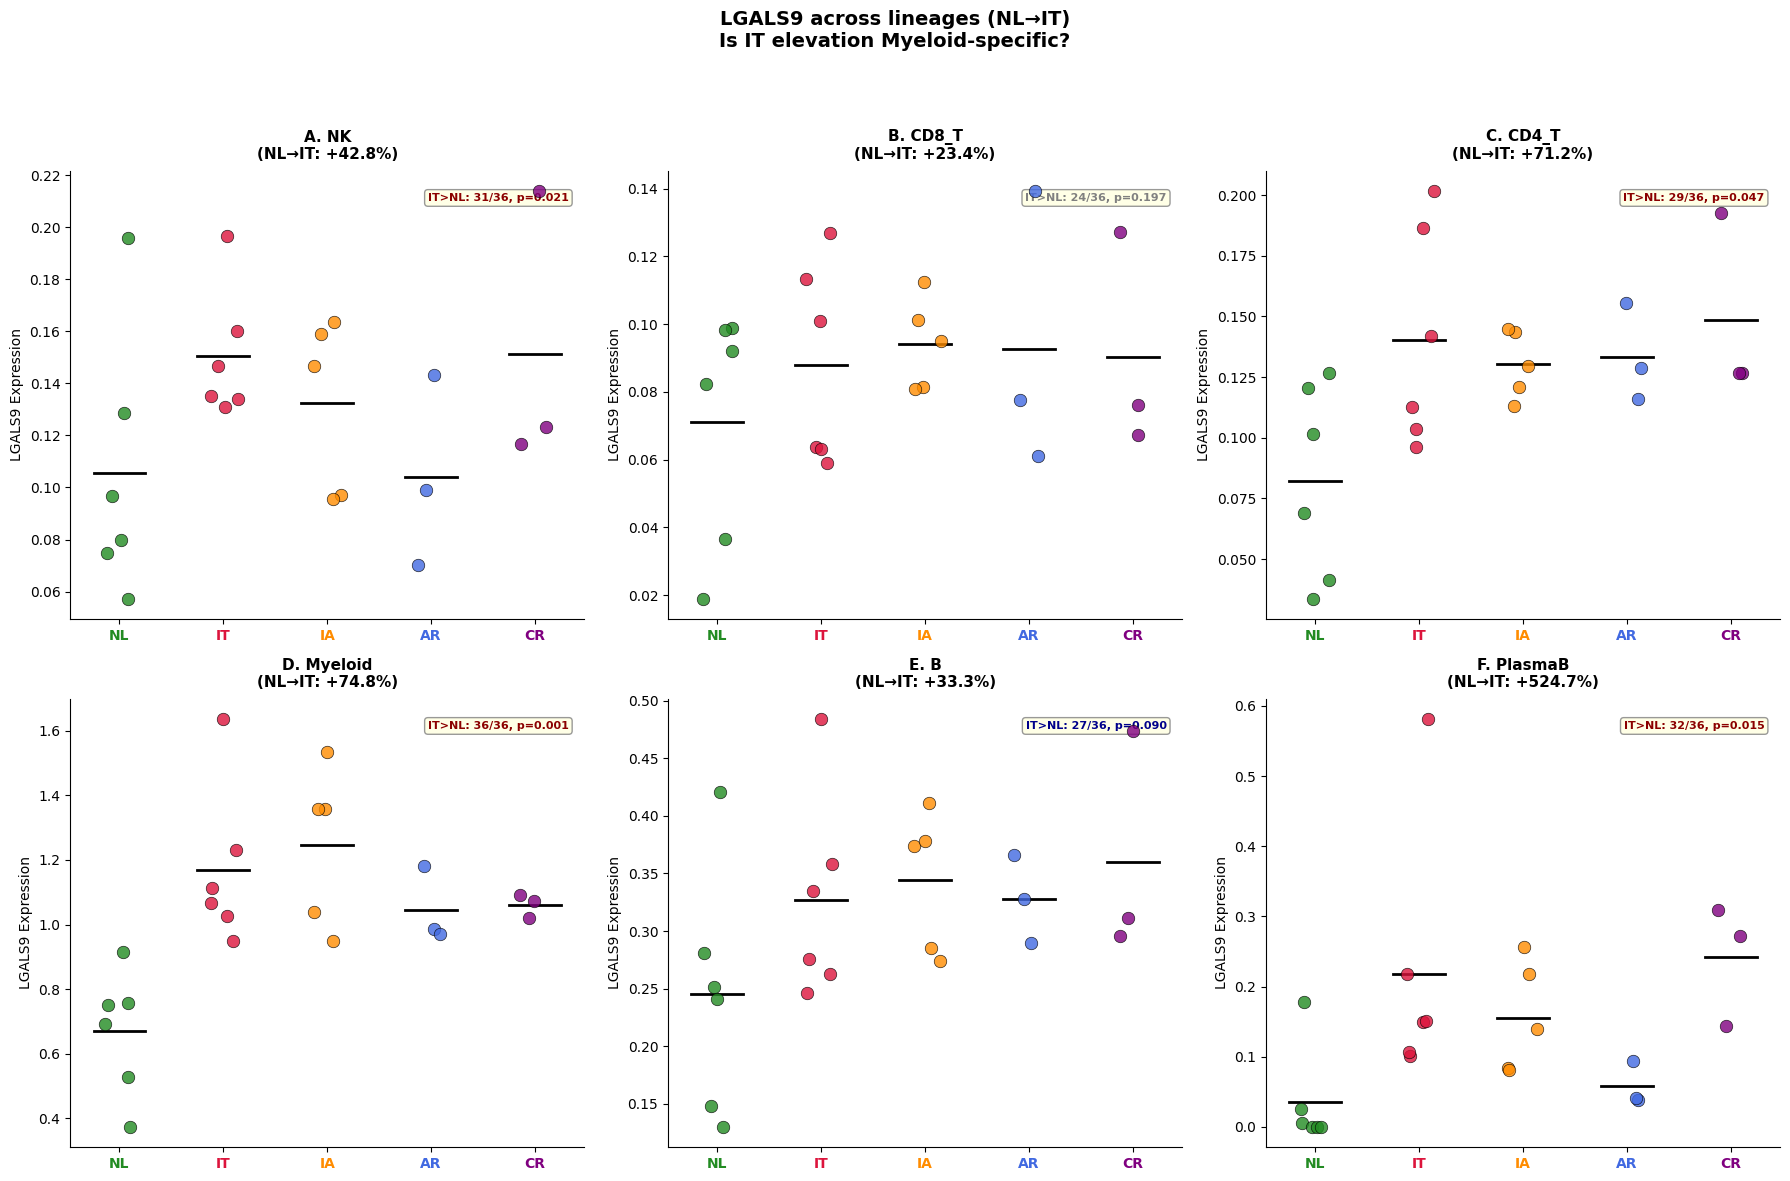

Saved: LGALS9 cross-lineage NL vs IT


In [21]:
# ============================================================
# PART 7: BRAKE GENES CROSS-LINEAGE — Myeloid-specific?
# ============================================================
print("\n" + "="*80)
print("PART 7: BRAKE GENES — CROSS-LINEAGE NL vs IT")
print("       Is the Firewall Myeloid-specific?")
print("="*80)

KEY_BRAKE_GENES = ['TNFAIP3', 'IDO1', 'LGALS9']

for gene in KEY_BRAKE_GENES:
    fig7, axes7 = plt.subplots(2, 3, figsize=(18, 12))
    fig7.suptitle(f'{gene} across lineages (NL→IT)\n'
                  f'Is IT elevation Myeloid-specific?',
                  fontsize=14, fontweight='bold', y=0.98)

    print(f"\n--- {gene} CROSS-LINEAGE: NL vs IT ---")

    for idx, lineage in enumerate(LINEAGES):
        ax = axes7[idx // 3, idx % 3]
        lin_mask = adata.obs['major_lineage'] == lineage
        adata_lin = adata[lin_mask]

        donor_df = get_donor_means(adata_lin, gene)
        if donor_df is None:
            print(f"  {lineage:10s}: {gene} not found")
            ax.text(0.5, 0.5, 'Gene not found', transform=ax.transAxes, ha='center')
            continue

        result = donor_test(donor_df, 'NL', 'IT')
        sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""

        print(f"  {lineage:10s}: NL={result['va'].mean():.4f} IT={result['vb'].mean():.4f} "
              f"({result['change']:+.1f}%) | {result['direction']}: "
              f"{result['consist']}/{result['total']}, p={result['p']:.3f}{sig}")

        plot_donor_dots(ax, donor_df,
                        f'{chr(65+idx)}. {lineage}\n(NL→IT: {result["change"]:+.1f}%)',
                        f'{gene} Expression')

        pcolor = 'darkred' if result['p'] < 0.05 else 'darkblue' if result['p'] < 0.1 else 'grey'
        label = f'{result["direction"]}: {result["consist"]}/{result["total"]}, p={result["p"]:.3f}'
        ax.text(0.97, 0.95, label, transform=ax.transAxes, fontsize=8,
                ha='right', va='top', color=pcolor, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          alpha=0.8, edgecolor='grey'))

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    fig7.savefig(os.path.join(SAVE_DIR, f'SupFig_{gene}_CrossLineage_NLvsIT.png'),
                 dpi=300, bbox_inches='tight', facecolor='white')
    fig7.savefig(os.path.join(SAVE_DIR, f'SupFig_{gene}_CrossLineage_NLvsIT.pdf'),
                 bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {gene} cross-lineage NL vs IT")

In [22]:
# ============================================================
# PART 8: IT→IA TRANSITION — Brake release validation
# ============================================================
print("\n" + "="*80)
print("PART 8: IT→IA TRANSITION — MYELOID BRAKE RELEASE?")
print("="*80)

ALL_KEY_GENES = ['NLRP3', 'IL1B', 'CASP1', 'GSDMD', 'IL18',
                 'TNFAIP3', 'IDO1', 'LGALS9', 'IL1RN', 'TGFB1']

print(f"\n{'Gene':<10s} {'IT mean':>10s} {'IA mean':>10s} {'IT→IA':>10s} "
      f"{'Direction':>12s} {'Consist':>10s} {'p-value':>10s} {'Category':>10s}")
print("-" * 95)

for gene in ALL_KEY_GENES:
    donor_df = get_donor_means(adata_myeloid, gene)
    if donor_df is None:
        continue

    result = donor_test(donor_df, 'IT', 'IA')
    category = "FIRE" if gene in ['NLRP3', 'IL1B', 'CASP1', 'GSDMD', 'IL18'] else "BRAKE"
    sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""

    print(f"  {gene:<10s} {result['va'].mean():>10.4f} {result['vb'].mean():>10.4f} "
          f"{result['change']:>+9.1f}% {result['direction']:>12s} "
          f"{result['consist']}/{result['total']} {result['p']:>10.3f}{sig}  {category}")

# Also test NL→IT for all
print(f"\n{'Gene':<10s} {'NL mean':>10s} {'IT mean':>10s} {'NL→IT':>10s} "
      f"{'Direction':>12s} {'Consist':>10s} {'p-value':>10s} {'Category':>10s}")
print("-" * 95)

for gene in ALL_KEY_GENES:
    donor_df = get_donor_means(adata_myeloid, gene)
    if donor_df is None:
        continue

    result = donor_test(donor_df, 'NL', 'IT')
    category = "FIRE" if gene in ['NLRP3', 'IL1B', 'CASP1', 'GSDMD', 'IL18'] else "BRAKE"
    sig = " **" if result['p'] < 0.05 else " *" if result['p'] < 0.1 else ""

    print(f"  {gene:<10s} {result['va'].mean():>10.4f} {result['vb'].mean():>10.4f} "
          f"{result['change']:>+9.1f}% {result['direction']:>12s} "
          f"{result['consist']}/{result['total']} {result['p']:>10.3f}{sig}  {category}")


PART 8: IT→IA TRANSITION — MYELOID BRAKE RELEASE?

Gene          IT mean    IA mean      IT→IA    Direction    Consist    p-value   Category
-----------------------------------------------------------------------------------------------
  NLRP3          0.3605     0.3079     -14.6%        IT>IA 21/30      0.165  FIRE
  IL1B           0.6965     0.6193     -11.1%        IT>IA 17/30      0.396  FIRE
  CASP1          1.1295     1.1687      +3.5%        IA>IT 17/30      0.396  FIRE
  GSDMD          0.3618     0.3240     -10.4%        IT>IA 18/30      0.331  FIRE
  IL18           0.2543     0.2447      -3.8%        IT>IA 17/30      0.396  FIRE
  TNFAIP3        0.4709     0.2845     -39.6%        IT>IA 21/30      0.165  BRAKE
  IDO1           0.0965     0.0714     -26.1%        IT>IA 21/30      0.165  BRAKE
  LGALS9         1.1703     1.2478      +6.6%        IA>IT 18/30      0.331  BRAKE
  IL1RN          0.3339     0.2431     -27.2%        IT>IA 19/30      0.268  BRAKE
  TGFB1          1.2

In [23]:
# ============================================================
# PART 9: GSDMD ASSEMBLY CHECKPOINT — Re-evaluation
# ============================================================
print("\n" + "="*80)
print("PART 9: GSDMD vs NLRP3 — ASSEMBLY CHECKPOINT RE-EVALUATION")
print("="*80)
print("Memory note: GSDMD correlation gap was negative (GSDMD ρ > core ρ)")
print("Evidence relies on fold change only (GSDMD +2% vs NLRP3 +95%)")
print("Need donor-level validation of this differential")

for gene in ['NLRP3', 'GSDMD']:
    donor_df = get_donor_means(adata_myeloid, gene)
    if donor_df is None:
        continue

    result_nl_it = donor_test(donor_df, 'NL', 'IT')

    # Also get fold change per donor (IT/NL)
    nl_vals = donor_df[donor_df['Stage'] == 'NL'].set_index('donor_id')['expression']
    it_vals = donor_df[donor_df['Stage'] == 'IT'].set_index('donor_id')['expression']

    print(f"\n  {gene}:")
    print(f"    NL mean: {result_nl_it['va'].mean():.4f}")
    print(f"    IT mean: {result_nl_it['vb'].mean():.4f}")
    print(f"    Change: {result_nl_it['change']:+.1f}%")
    print(f"    Consistency: {result_nl_it['consist']}/{result_nl_it['total']}")
    print(f"    p-value: {result_nl_it['p']:.3f}")

# Compute NLRP3/GSDMD ratio per donor
print("\n  NLRP3 vs GSDMD differential (per donor):")
nlrp3_df = get_donor_means(adata_myeloid, 'NLRP3')
gsdmd_df = get_donor_means(adata_myeloid, 'GSDMD')

if nlrp3_df is not None and gsdmd_df is not None:
    for stage in ['NL', 'IT']:
        n3 = nlrp3_df[nlrp3_df['Stage'] == stage].set_index('donor_id')['expression']
        gd = gsdmd_df[gsdmd_df['Stage'] == stage].set_index('donor_id')['expression']
        common = n3.index.intersection(gd.index)
        if len(common) > 0:
            ratios = n3.loc[common] / (gd.loc[common] + 1e-6)
            print(f"    {stage}: NLRP3/GSDMD ratio = {ratios.mean():.2f} "
                  f"(range: {ratios.min():.2f}-{ratios.max():.2f})")


PART 9: GSDMD vs NLRP3 — ASSEMBLY CHECKPOINT RE-EVALUATION
Memory note: GSDMD correlation gap was negative (GSDMD ρ > core ρ)
Evidence relies on fold change only (GSDMD +2% vs NLRP3 +95%)
Need donor-level validation of this differential

  NLRP3:
    NL mean: 0.3758
    IT mean: 0.3605
    Change: -4.0%
    Consistency: 22/36
    p-value: 0.294

  GSDMD:
    NL mean: 0.3036
    IT mean: 0.3618
    Change: +19.2%
    Consistency: 25/36
    p-value: 0.155

  NLRP3 vs GSDMD differential (per donor):
    NL: NLRP3/GSDMD ratio = 1.25 (range: 0.59-1.99)
    IT: NLRP3/GSDMD ratio = 1.07 (range: 0.60-2.13)


In [24]:
# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: MYELOID INFLAMMASOME PARADOX")
print("="*80)

print(f"\n{'Category':<12s} {'Gene':<10s} {'NL→IT':>8s} {'Consist':>10s} "
      f"{'p-value':>8s} {'Status':>12s}")
print("=" * 65)

for gene in INFLAMMASOME_GENES:
    if gene in inflamm_results:
        r = inflamm_results[gene]
        sig = "★★" if r['p'] < 0.05 else "★" if r['p'] < 0.1 else "NS"
        status = "CONFIRMED" if r['p'] < 0.05 else "TREND" if r['p'] < 0.1 else "WEAK/NS"
        print(f"  {'FIRE':<12s} {gene:<10s} {r['change']:>+7.1f}% "
              f"{r['consist']}/{r['total']} {r['p']:>8.3f}  {status}")

print()
for gene in BRAKE_GENES:
    if gene in brake_results:
        r = brake_results[gene]
        sig = "★★" if r['p'] < 0.05 else "★" if r['p'] < 0.1 else "NS"
        status = "CONFIRMED" if r['p'] < 0.05 else "TREND" if r['p'] < 0.1 else "WEAK/NS"
        print(f"  {'FIREWALL':<12s} {gene:<10s} {r['change']:>+7.1f}% "
              f"{r['consist']}/{r['total']} {r['p']:>8.3f}  {status}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE — Results saved to:", SAVE_DIR)
print("="*80)
print("\nNEXT: B cell lineage donor-level validation")


COMPREHENSIVE SUMMARY: MYELOID INFLAMMASOME PARADOX

Category     Gene          NL→IT    Consist  p-value       Status
  FIRE         NLRP3         -4.0% 22/36    0.294  WEAK/NS
  FIRE         PYCARD       +20.6% 30/36    0.032  CONFIRMED
  FIRE         CASP1        +58.7% 33/36    0.008  CONFIRMED
  FIRE         IL1B          -4.7% 20/36    0.409  WEAK/NS
  FIRE         IL18          +8.0% 22/36    0.294  WEAK/NS
  FIRE         GSDMD        +19.2% 25/36    0.155  WEAK/NS
  FIRE         AIM2        +430.7% 33/36    0.010  CONFIRMED
  FIRE         NLRC4        +82.0% 32/36    0.013  CONFIRMED
  FIRE         MEFV        +122.0% 32/36    0.013  CONFIRMED

  FIREWALL     TNFAIP3      +19.6% 21/36    0.350  WEAK/NS
  FIREWALL     IDO1         +80.1% 20/36    0.409  WEAK/NS
  FIREWALL     LGALS9       +74.8% 36/36    0.001  CONFIRMED
  FIREWALL     IL1RN         -0.8% 19/36    0.469  WEAK/NS
  FIREWALL     TGFB1        +52.4% 33/36    0.008  CONFIRMED

ANALYSIS COMPLETE — Results saved to: 